# ⚠️ **Advertencia de uso responsable** 
> Desarrollo con fines exclusivamente académicos. No constituye un dispositivo médico, no ha sido validado clínicamente y no debe utilizarse para apoyar decisiones quirúrgicas reales.

# EDA: dataset PENGWIN

Análisis exploratorio de tomografías computarizadas (CT) de fractura pélvica y de sus máscaras de fragmentos, del dataset [PENGWIN](https://pengwin.grand-challenge.org/) (MICCAI 2024-2026).

Contenido:

1. Rutas, parámetros e inventario de casos.
2. Pipeline de preprocesamiento: carga, reorientación, recorte, ventaneo HU y normalización.
3. Estadísticas por caso (geometría, fragmentos, histogramas HU).
4. Geometría: espaciado, orientación, recorte y anisotropía.
5. Intensidades HU: ventana, histograma y caso de HU óseo bajo.
6. Fragmentos: número, volumen, tipo de fractura y conectividad.
7. Anomalías marcadas, ejemplos y splits fijos.

## Imports y parámetros

In [1]:
from pathlib import Path
import sys
import time

import numpy as np
import pandas as pd
import torch
import SimpleITK as sitk
import matplotlib.pyplot as plt
from matplotlib import patches as mpatches
from matplotlib.colors import ListedColormap
from tqdm.auto import tqdm

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src import config
from src.dataset import preprocessing as pre

plt.rcParams["figure.dpi"] = 110

SEED = config.SEED
torch.manual_seed(SEED)
np.random.seed(SEED)

# GPU cuando está disponible, CPU como respaldo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.zeros(1, device=device)

print("Imports OK - SimpleITK", sitk.__version__)
print("Dispositivo:", device, "| torch", torch.__version__)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

Imports OK - SimpleITK 2.5.6
Dispositivo: cpu | torch 2.14.0


/Users/estefania/Downloads/Proyecto 2/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Los parámetros del pipeline (`HU_LO`, `HU_HI`, `CROP_MM`, orientación) se leen de `src/config.py`, el mismo archivo que usa la inferencia. El resto de parámetros del análisis se edita en la celda siguiente.

In [2]:
# Rutas (relativas a la raíz del proyecto)
DATA_DIR    = PROJECT_ROOT / "data"
IMAGES_DIRS = [DATA_DIR / "PENGWIN_CT_train_images_part1",   # CT 001-050
               DATA_DIR / "PENGWIN_CT_train_images_part2"]   # CT 051-100
LABELS_DIR  = DATA_DIR / "PENGWIN_CT_train_labels"           # máscaras 001-100
OUT_DIR     = PROJECT_ROOT / "results" / "eda"                            # tablas y figuras
SPLITS_DIR  = PROJECT_ROOT / "splits"
OUT_DIR.mkdir(parents=True, exist_ok=True)
SPLITS_DIR.mkdir(exist_ok=True)

# Pipeline (src/config.py)
HU_LO, HU_HI = config.HU_WINDOW
CROP_MM = config.CROP_MM

# Parámetros del análisis
RECALCULAR = True                # True: recorre los 100 volúmenes; False: carga las tablas guardadas en OUT_DIR
CASE_ID = "004"                  # caso de las secciones de un solo caso
UMBRAL_ANISOTROPIA = 1.5         # cociente máx/mín del espaciado a partir del cual se marca un caso
UMBRAL_FRAGMENTO_MM3 = 500       # volumen mínimo esperado de un fragmento (mm³)
UMBRAL_HU_OSEO_BAJO = 100        # mediana HU dentro de la máscara por debajo de la cual se marca un caso
LIMITES_INFERIORES_HU = [-500, -200, -100, 0, 50, 100, 200, 300]   # límites inferiores de ventana que se comparan
CASOS_EJEMPLO = ["001", "002", "095", "023"]            # cortes axiales de ejemplo
CASO_HU_BAJO = "095"                                     # caso de la sección de HU óseo bajo
FRAGMENTOS_CONECTIVIDAD = [("023", 12), ("064", 2)]      # (caso, código de fragmento) de la sección de conectividad
HU_HIST_LO, HU_HIST_HI = -3100, 4200   # rango del histograma HU; los valores fuera se acumulan en los extremos

# Taxonomía: código de fragmento -> región (1-10 sacro, 11-20 coxal izquierdo, 21-30 coxal derecho)
REGIONES = {"sacrum": range(1, 11), "left_hipbone": range(11, 21), "right_hipbone": range(21, 31)}
REGION_ORDER = list(REGIONES)
COLOR_REGION = {"sacrum": "#1b9e77", "left_hipbone": "#d95f02", "right_hipbone": "#7570b3"}
NOMBRE_REGION = {"sacrum": "Sacro", "left_hipbone": "Coxal izq.", "right_hipbone": "Coxal der."}

# Código de fragmento -> índice de región (0 = fondo), para colorear por región
lut = np.zeros(256, dtype=np.uint8)
for k, cods in enumerate(REGIONES.values(), start=1):
    lut[list(cods)] = k
cmap_reg = ListedColormap(["none", *COLOR_REGION.values()])

## Inventario de casos

Cada caso debe tener exactamente un CT y una máscara con el mismo identificador (`001`-`100`). El inventario se guarda en `data/inventario_pengwin.csv`.

In [3]:
for d in [*IMAGES_DIRS, LABELS_DIR]:
    archivos = sorted(d.glob("*.mha"))
    gb = sum(f.stat().st_size for f in archivos) / 1e9
    print(f"{d.name:34s} {len(archivos):4d} archivos  {gb:6.2f} GB")

img_paths = {f.stem: f for d in IMAGES_DIRS for f in sorted(d.glob("*.mha"))}
lbl_paths = {f.stem: f for f in sorted(LABELS_DIR.glob("*.mha"))}
print(f"\nSolo en imágenes: {sorted(img_paths.keys() - lbl_paths.keys()) or 'ninguno'}")
print(f"Solo en máscaras: {sorted(lbl_paths.keys() - img_paths.keys()) or 'ninguno'}")
assert img_paths.keys() == lbl_paths.keys(), "Hay casos sin emparejar: revisa las carpetas de datos."

df_inv = pd.DataFrame({"case_id": sorted(img_paths)})
df_inv["imagen"]     = df_inv["case_id"].map(lambda i: str(img_paths[i]))
df_inv["mascara"]    = df_inv["case_id"].map(lambda i: str(lbl_paths[i]))
df_inv["imagen_MB"]  = df_inv["imagen"].map(lambda p: round(Path(p).stat().st_size / 1e6, 1))
df_inv["mascara_MB"] = df_inv["mascara"].map(lambda p: round(Path(p).stat().st_size / 1e6, 1))
df_inv.to_csv(DATA_DIR / "inventario_pengwin.csv", index=False)
df_inv.head()

PENGWIN_CT_train_images_part1        50 archivos   11.08 GB
PENGWIN_CT_train_images_part2        50 archivos    9.11 GB
PENGWIN_CT_train_labels             100 archivos   13.58 GB

Solo en imágenes: ninguno
Solo en máscaras: ninguno


,case_id,imagen,mascara,imagen_MB,mascara_MB
0,001,/Users/estefania/Downloads/Proyecto 2/data/PEN...,/Users/estefania/Downloads/Proyecto 2/data/PEN...,420.5,210.2
1,002,/Users/estefania/Downloads/Proyecto 2/data/PEN...,/Users/estefania/Downloads/Proyecto 2/data/PEN...,153.7,76.8
2,003,/Users/estefania/Downloads/Proyecto 2/data/PEN...,/Users/estefania/Downloads/Proyecto 2/data/PEN...,222.4,111.2
3,004,/Users/estefania/Downloads/Proyecto 2/data/PEN...,/Users/estefania/Downloads/Proyecto 2/data/PEN...,87.8,43.9
4,005,/Users/estefania/Downloads/Proyecto 2/data/PEN...,/Users/estefania/Downloads/Proyecto 2/data/PEN...,327.2,163.6


## Pipeline de preprocesamiento

Los pasos están implementados en `src/dataset/preprocessing.py` y son los mismos para el EDA, el entrenamiento y la inferencia:

1. **Carga** (`load_volume`): `SimpleITK` devuelve el array en orden **(Z, Y, X)** y la geometría física (espaciado `(x, y, z)` en mm, origen y dirección).
2. **Reorientación** (`reorient`): lleva todos los volúmenes a la orientación `config.TARGET_ORIENTATION`. No interpola, así que sirve también para las máscaras.
3. **Recorte** (`crop_center`): recorta el plano axial a `CROP_MM` milímetros, centrado en el volumen, y rellena si el volumen es más pequeño (imagen con `config.PAD_HU`, máscara con 0). z no se recorta.
4. **Ventaneo HU y normalización** (`window_hu`): recorta los valores a `[HU_LO, HU_HI]` y los reescala linealmente a `[0, 1]`.

Unidades Hounsfield (HU): aire ≈ −1000, grasa ≈ −100, agua = 0, músculo ≈ 40, hueso esponjoso ≈ 200-300, hueso cortical ≈ 500-1500, metal > 3000.

In [4]:
img_raw = pre.load_volume(img_paths[CASE_ID])
msk_raw = pre.load_volume(lbl_paths[CASE_ID])
assert img_raw.GetSize() == msk_raw.GetSize(), "Imagen y máscara difieren en geometría"

# Los cuatro pasos por separado, para ver el efecto de cada uno
img_o = pre.reorient(img_raw)
img_c = pre.crop_center(img_o, CROP_MM, fill=config.PAD_HU)
img_w = pre.window_hu(sitk.GetArrayFromImage(img_c))

# Los cuatro pasos juntos, sobre imagen y máscara: HU y máscara listas para el resto del notebook
res = pre.preprocess_volume(img_raw, msk_raw)
img, msk = res["hu"], res["mask"]           # (Z, Y, X)
assert np.array_equal(img_w, res["image"])

pasos = pd.DataFrame({
    "tamaño (x, y, z)": [img_raw.GetSize(), img_o.GetSize(), img_c.GetSize()],
    "espaciado (mm)": [tuple(round(s, 4) for s in v.GetSpacing()) for v in (img_raw, img_o, img_c)],
    "dirección": [" ".join(f"{d:g}" for d in v.GetDirection()) for v in (img_raw, img_o, img_c)],
    "origen (mm)": [tuple(round(o, 1) for o in v.GetOrigin()) for v in (img_raw, img_o, img_c)],
}, index=["1. carga", "2. reorientación", "3. recorte"])
print(f"Caso {CASE_ID}: {img_raw.GetPixelIDTypeAsString()}, HU [{sitk.GetArrayFromImage(img_raw).min()}, {sitk.GetArrayFromImage(img_raw).max()}], "
      f"vóxel {np.prod(img_raw.GetSpacing()):.4f} mm³")
print(f"Tras la ventana [{HU_LO:.0f}, {HU_HI:.0f}]: dtype {img_w.dtype}, rango [{img_w.min():.2f}, {img_w.max():.2f}]")
pasos

Caso 004: 32-bit signed integer, HU [-1418, 4961], vóxel 0.7119 mm³
Tras la ventana [50, 1300]: dtype float32, rango [0.00, 1.00]


,"tamaño (x, y, z)",espaciado (mm),dirección,origen (mm)
1. carga,"(386, 254, 224)","(0.8438, 0.8438, 1.0)",-1 0 0 0 -1 0 0 0 1,"(158.2, 105.4, -1284.6)"
2. reorientación,"(386, 254, 224)","(0.8438, 0.8438, 1.0)",1 0 0 0 1 0 0 0 1,"(-166.7, -108.1, -1284.6)"
3. recorte,"(415, 415, 224)","(0.8438, 0.8438, 1.0)",1 0 0 0 1 0 0 0 1,"(-179.3, -176.5, -1284.6)"


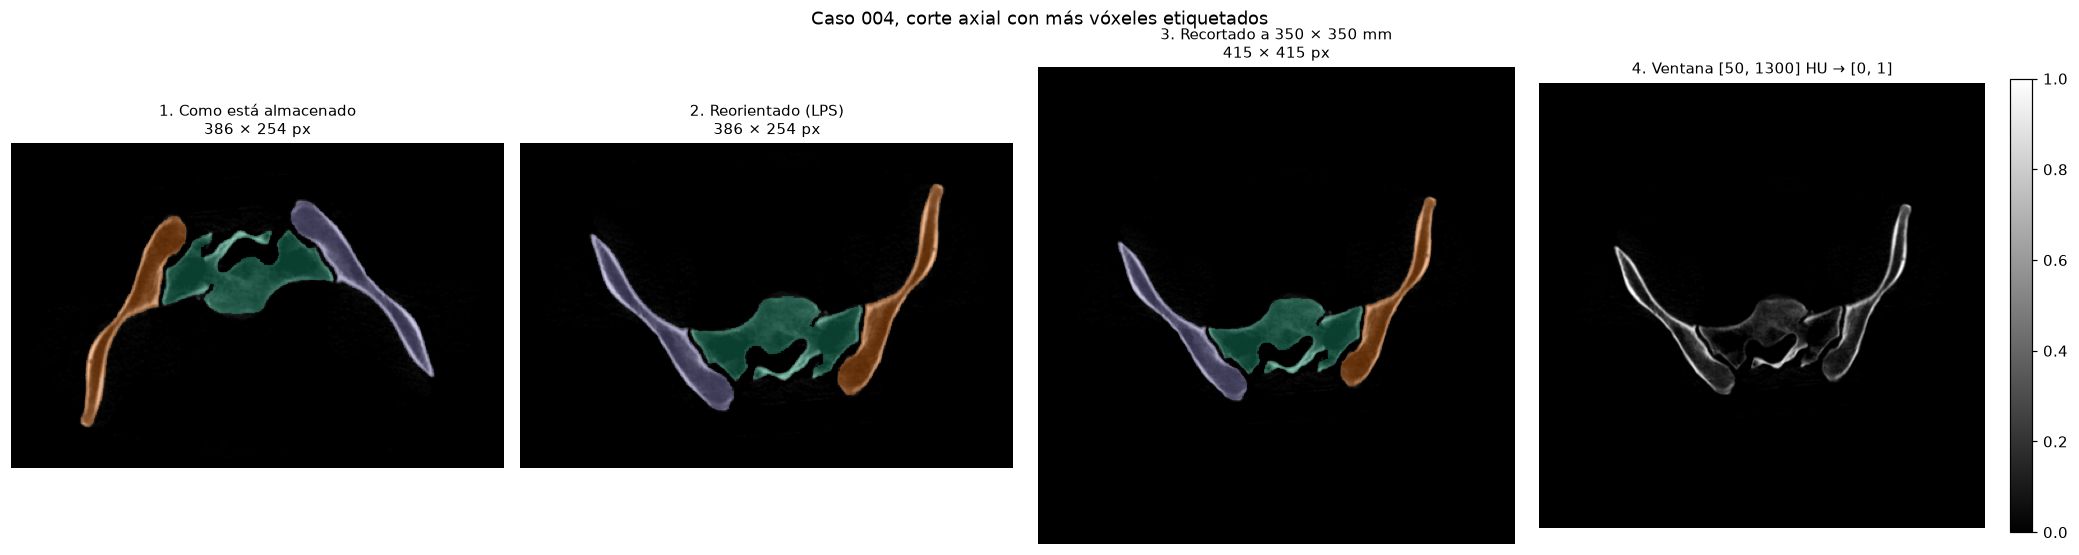

In [5]:
corte_max = lambda m: int((m > 0).reshape(m.shape[0], -1).sum(1).argmax())   # corte axial con más vóxeles etiquetados

a_raw, m_raw = sitk.GetArrayFromImage(img_raw), sitk.GetArrayFromImage(msk_raw)
a_o, m_o = sitk.GetArrayFromImage(img_o), sitk.GetArrayFromImage(pre.reorient(msk_raw))
z_raw, z_o, z_c = corte_max(m_raw), corte_max(m_o), corte_max(msk)

fig, axes = plt.subplots(1, 4, figsize=(19, 5))
for ax, corte, mascara, titulo in [
        (axes[0], a_raw[z_raw], m_raw[z_raw], "1. Como está almacenado"),
        (axes[1], a_o[z_o], m_o[z_o], f"2. Reorientado ({config.TARGET_ORIENTATION})"),
        (axes[2], img[z_c], msk[z_c], f"3. Recortado a {CROP_MM[0]:.0f} × {CROP_MM[1]:.0f} mm")]:
    ax.imshow(np.clip(corte, HU_LO, HU_HI), cmap="gray")
    ax.imshow(np.ma.masked_equal(lut[np.clip(mascara, 0, 255)], 0), cmap=cmap_reg, vmin=0, vmax=3, alpha=0.4, interpolation="nearest")
    ax.set_title(f"{titulo}\n{corte.shape[1]} × {corte.shape[0]} px", fontsize=10); ax.axis("off")
im = axes[3].imshow(img_w[z_c], cmap="gray", vmin=0, vmax=1)
axes[3].set_title(f"4. Ventana [{HU_LO:.0f}, {HU_HI:.0f}] HU → [0, 1]", fontsize=10); axes[3].axis("off")
fig.colorbar(im, ax=axes[3], fraction=0.046)
fig.suptitle(f"Caso {CASE_ID}, corte axial con más vóxeles etiquetados", y=1.0)
plt.tight_layout()
plt.savefig(OUT_DIR / "preprocessing_steps.png", bbox_inches="tight", dpi=150)
plt.show()

## Estadísticas por caso

Recorre los 100 volúmenes una vez, aplicando el pipeline, y construye:

- `df`: una fila por caso. La geometría, la orientación y los HU mínimo/máximo son los del volumen tal como está almacenado; los fragmentos y los histogramas HU son los del volumen reorientado; el recorte se resume en `crop_*`, `pad_*` y `frac_hueso_perdido_crop`.
- `df_frag`: una fila por fragmento (código, región, volumen en mm³, componentes conexas con vecindad de 6 y de 26, tamaño de cada componente, extensión y centroide).
- `H_todo`, `H_hueso`: histogramas HU (1 HU por bin) por caso, de todo el volumen y solo de los vóxeles etiquetados.

El **tipo de fractura** se deriva del número de fragmentos por región (más de un fragmento = región fracturada): `PRD` sin fractura dentro de un hueso, `UHF` coxal unilateral, `BHF` coxal bilateral, `SF` sacro, `SHF` sacro y coxal.

Con `RECALCULAR = False` las tres estructuras se cargan de `OUT_DIR` sin releer los volúmenes.

In [6]:
NB = HU_HIST_HI - HU_HIST_LO + 1
CHUNK = 32   # cortes por bloque al histogramar

if RECALCULAR:
    filas, filas_frag = [], []
    H_todo  = np.zeros((len(df_inv), NB), dtype=np.int64)
    H_hueso = np.zeros((len(df_inv), NB), dtype=np.int64)
    mm = sitk.MinimumMaximumImageFilter()

    for i, cid in enumerate(tqdm(df_inv["case_id"], desc="Casos")):
        v_img, v_msk = pre.load_volume(img_paths[cid]), pre.load_volume(lbl_paths[cid])
        sx, sy, sz = v_msk.GetSpacing()
        vox_mm3 = sx * sy * sz

        # Campos del header que SimpleITK no expone
        hdr = {}
        with open(img_paths[cid], "rb") as f:
            for linea in f:
                k, _, v = linea.decode("latin-1").strip().partition(" = ")
                hdr[k] = v
                if k == "ElementDataFile":
                    break
        itk_orig = tuple(float(v) for v in hdr["ITK_original_spacing"].split()) if "ITK_original_spacing" in hdr else (np.nan,) * 3

        mm.Execute(v_img); hu_min, hu_max = int(mm.GetMinimum()), int(mm.GetMaximum())
        mm.Execute(v_msk); lab_min, lab_max = int(mm.GetMinimum()), int(mm.GetMaximum())
        fila = {
            "case_id": cid, "part": img_paths[cid].parent.name.rsplit("_", 1)[-1],
            "dim_x": v_msk.GetSize()[0], "dim_y": v_msk.GetSize()[1], "dim_z": v_msk.GetSize()[2],
            "spacing_x": sx, "spacing_y": sy, "spacing_z": sz,
            "itk_orig_spacing_x": itk_orig[0], "itk_orig_spacing_y": itk_orig[1], "itk_orig_spacing_z": itk_orig[2],
            "origin_x": v_msk.GetOrigin()[0], "origin_y": v_msk.GetOrigin()[1], "origin_z": v_msk.GetOrigin()[2],
            "direction": " ".join(f"{d:g}" for d in v_msk.GetDirection()),
            "orientation": hdr.get("AnatomicalOrientation"),
            "image_dtype": hdr.get("ElementType"),
            "geometry_match": bool(v_img.GetSize() == v_msk.GetSize()
                                   and np.allclose(v_img.GetSpacing(), v_msk.GetSpacing(), atol=1e-6)
                                   and np.allclose(v_img.GetOrigin(), v_msk.GetOrigin(), atol=1e-4)
                                   and np.allclose(v_img.GetDirection(), v_msk.GetDirection())),
            "hu_min": hu_min, "hu_max": hu_max, "label_min": lab_min, "label_max": lab_max,
        }

        # Posición de cada región en el array tal como está almacenado (antes de reorientar)
        lss = sitk.LabelShapeStatisticsImageFilter(); lss.Execute(v_msk)
        for r, cods in REGIONES.items():
            cs = [c for c in lss.GetLabels() if c in cods]
            pos = [v_msk.TransformPhysicalPointToContinuousIndex(lss.GetCentroid(c)) for c in cs]
            w = [lss.GetNumberOfPixels(c) for c in cs]
            fila[f"centroid_idx_x_original_{r}"] = np.average([p[0] for p in pos], weights=w) if cs else np.nan
            fila[f"centroid_idx_y_original_{r}"] = np.average([p[1] for p in pos], weights=w) if cs else np.nan

        # Pipeline: reorientación y recorte
        v_img, v_msk = pre.reorient(v_img), pre.reorient(v_msk)
        v_msk_c = pre.crop_center(v_msk, CROP_MM, fill=0)
        nx_o, ny_o = v_msk.GetSize()[:2]
        nx_c, ny_c = v_msk_c.GetSize()[:2]
        fila.update({"crop_dim_x": nx_c, "crop_dim_y": ny_c, "pad_x": max(nx_c - nx_o, 0), "pad_y": max(ny_c - ny_o, 0),
                     "crop_pad_frac": 1 - min(nx_o, nx_c) * min(ny_o, ny_c) / (nx_c * ny_c),
                     "direction_pipeline": " ".join(f"{d:g}" for d in v_msk.GetDirection())})

        # Fragmentos (volumen reorientado, sin recorte)
        lss = sitk.LabelShapeStatisticsImageFilter(); lss.Execute(v_msk)
        lss_c = sitk.LabelShapeStatisticsImageFilter(); lss_c.Execute(v_msk_c)
        codigos = sorted(lss.GetLabels())
        perdido = {c: lss.GetNumberOfPixels(c) - (lss_c.GetNumberOfPixels(c) if c in lss_c.GetLabels() else 0) for c in codigos}
        frags_caso = []
        for code in codigos:
            n_vox = lss.GetNumberOfPixels(code)
            cen = lss.GetCentroid(code)
            cen_idx = v_msk.TransformPhysicalPointToContinuousIndex(cen)
            bx, by, bz, nx, ny, nz = lss.GetBoundingBox(code)
            recorte = sitk.GetArrayFromImage(sitk.RegionOfInterest(v_msk, size=(nx, ny, nz), index=(bx, by, bz)))
            frag = sitk.GetImageFromArray((recorte == code).astype(np.uint8))
            tam = {}
            for vecinos, full in ((6, False), (26, True)):
                cc = sitk.GetArrayFromImage(sitk.ConnectedComponent(frag, full))
                tam[vecinos] = np.sort(np.bincount(cc.ravel())[1:])[::-1]   # tamaño de cada componente, de mayor a menor
            region = next((r for r, c in REGIONES.items() if code in c), None)
            frags_caso.append({
                "case_id": cid, "code": code, "region": region,
                "voxels": n_vox, "volume_mm3": n_vox * vox_mm3, "voxels_perdidos_crop": perdido[code],
                "n_components_6": len(tam[6]), "n_components_26": len(tam[26]),
                "largest_component_frac_6": tam[6][0] / n_vox, "largest_component_frac_26": tam[26][0] / n_vox,
                "comp_sizes_6": ";".join(map(str, tam[6])), "comp_sizes_26": ";".join(map(str, tam[26])),
                "extent_x_mm": nx * sx, "extent_y_mm": ny * sy, "extent_z_mm": nz * sz,
                "centroid_x_mm": cen[0], "centroid_y_mm": cen[1], "centroid_z_mm": cen[2],
                "centroid_idx_x": cen_idx[0], "centroid_idx_y": cen_idx[1], "centroid_idx_z": cen_idx[2],
            })
        filas_frag += frags_caso
        fila["codes"] = " ".join(map(str, codigos))
        fila["frac_hueso_perdido_crop"] = sum(perdido.values()) / sum(lss.GetNumberOfPixels(c) for c in codigos)
        fila["frags_cortados_crop"] = sum(v > 0 for v in perdido.values())

        # Resumen por región
        n_frag = {}
        for r in REGION_ORDER:
            fr = [f for f in frags_caso if f["region"] == r]
            n_frag[r] = len(fr)
            fila[f"n_frag_{r}"] = len(fr)
            fila[f"volume_mm3_{r}"] = sum(f["volume_mm3"] for f in fr)
            for eje in ("x", "y"):
                if fr:
                    w = np.array([f["voxels"] for f in fr], dtype=float)
                    fila[f"centroid_{eje}_mm_{r}"] = np.average([f[f"centroid_{eje}_mm"] for f in fr], weights=w)
                    fila[f"centroid_idx_{eje}_{r}"] = np.average([f[f"centroid_idx_{eje}"] for f in fr], weights=w)
                else:
                    fila[f"centroid_{eje}_mm_{r}"] = fila[f"centroid_idx_{eje}_{r}"] = np.nan
            if fr:
                por_codigo, por_volumen = sorted(fr, key=lambda f: f["code"]), sorted(fr, key=lambda f: -f["voxels"])
                fila[f"main_is_first_code_{r}"] = por_codigo[0]["code"] == por_volumen[0]["code"]
                fila[f"codes_sorted_by_volume_{r}"] = [f["code"] for f in por_codigo] == [f["code"] for f in por_volumen]
        fila["n_fragments"] = len(frags_caso)
        caderas_fx = int(n_frag["left_hipbone"] > 1) + int(n_frag["right_hipbone"] > 1)
        fila["fracture_type"] = ("SF" if caderas_fx == 0 else "SHF") if n_frag["sacrum"] > 1 else ("PRD", "UHF", "BHF")[caderas_fx]
        fila["bone_volume_mm3"] = sum(f["volume_mm3"] for f in frags_caso)

        # Histogramas HU del volumen reorientado
        a_img, a_msk = sitk.GetArrayFromImage(v_img), sitk.GetArrayFromImage(v_msk)
        for z0 in range(0, a_img.shape[0], CHUNK):
            b = np.clip(a_img[z0:z0 + CHUNK], HU_HIST_LO, HU_HIST_HI) - HU_HIST_LO
            H_todo[i]  += np.bincount(b.ravel(), minlength=NB)
            H_hueso[i] += np.bincount(b[a_msk[z0:z0 + CHUNK] > 0], minlength=NB)
        filas.append(fila)

    df = pd.DataFrame(filas)
    df_frag = pd.DataFrame(filas_frag)
    df.to_csv(OUT_DIR / "case_table.csv", index=False)
    df_frag.to_csv(OUT_DIR / "fragments.csv", index=False)
    np.savez_compressed(OUT_DIR / "hu_hist_por_caso.npz", todo=H_todo, hueso=H_hueso, case_id=df["case_id"].to_numpy())
else:
    df = pd.read_csv(OUT_DIR / "case_table.csv", dtype={"case_id": str})
    df_frag = pd.read_csv(OUT_DIR / "fragments.csv", dtype={"case_id": str})
    npz = np.load(OUT_DIR / "hu_hist_por_caso.npz", allow_pickle=True)
    H_todo, H_hueso = npz["todo"], npz["hueso"]

# Percentiles HU a partir de los histogramas por caso
bins_hu = np.arange(HU_HIST_LO, HU_HIST_HI + 1)
cum_todo, cum_hueso = np.cumsum(H_todo, axis=1), np.cumsum(H_hueso, axis=1)
for nombre, cum, q in [("hu_p01", cum_todo, 0.01), ("hu_p50", cum_todo, 0.50), ("hu_p99", cum_todo, 0.99),
                       ("bone_hu_p05", cum_hueso, 0.05), ("bone_hu_p50", cum_hueso, 0.50), ("bone_hu_p95", cum_hueso, 0.95)]:
    df[nombre] = HU_HIST_LO + (cum < q * cum[:, -1:]).sum(axis=1)
df["bone_hu_mean"] = (H_hueso * bins_hu).sum(axis=1) / H_hueso.sum(axis=1)

# Geometría derivada
esp = df[["spacing_x", "spacing_y", "spacing_z"]]
df["voxel_mm3"] = esp.prod(axis=1)
df["anisotropia"] = esp.max(axis=1) / esp.min(axis=1)
df["fov_x_mm"], df["fov_y_mm"], df["fov_z_mm"] = df.dim_x * df.spacing_x, df.dim_y * df.spacing_y, df.dim_z * df.spacing_z

print(f"{len(df)} casos, {len(df_frag)} fragmentos")
df.head()

Casos: 100%|██████████| 100/100 [01:15<00:00,  1.33it/s]


100 casos, 575 fragmentos


,case_id,part,dim_x,dim_y,dim_z,spacing_x,spacing_y,spacing_z,itk_orig_spacing_x,itk_orig_spacing_y,...,hu_p99,bone_hu_p05,bone_hu_p50,bone_hu_p95,bone_hu_mean,voxel_mm3,anisotropia,fov_x_mm,fov_y_mm,fov_z_mm
0,001,part1,512,512,401,0.781250,0.781250,0.8,0.781250,0.8,...,507,-97,173,1124,292.323379,0.488281,1.024000,400.000000,400.000000,320.800005
1,002,part1,413,276,337,0.824219,0.824219,0.8,0.824219,0.8,...,593,27,252,880,324.672592,0.543469,1.030273,340.402344,227.484375,269.600004
2,003,part1,512,381,285,0.759766,0.759766,1.0,0.759766,1.0,...,625,111,410,1049,476.937360,0.577244,1.316195,389.000000,289.470703,285.000000
3,004,part1,386,254,224,0.843750,0.843750,1.0,0.843750,1.0,...,698,88,330,1010,413.176674,0.711914,1.185185,325.687500,214.312500,224.000000
4,005,part1,512,512,312,0.896484,0.896484,1.0,0.896484,1.0,...,304,101,336,983,413.179676,0.803684,1.115468,459.000000,459.000000,312.000000


### Cobertura

In [7]:
print("Casos por carpeta de imágenes:", df.part.value_counts().to_dict())
print("Imagen y máscara con la misma geometría (tamaño, espaciado, origen, dirección):", int(df.geometry_match.sum()), "/", len(df))
print("Tipo de dato de la imagen:", df.image_dtype.value_counts().to_dict())
print("Rango de etiquetas:", int(df.label_min.min()), "a", int(df.label_max.max()))

Casos por carpeta de imágenes: {'part1': 50, 'part2': 50}
Imagen y máscara con la misma geometría (tamaño, espaciado, origen, dirección): 100 / 100
Tipo de dato de la imagen: {'MET_INT': 53, 'MET_SHORT': 47}
Rango de etiquetas: 0 a 24


## Geometría

Dimensiones y espaciado por caso, del volumen tal como está almacenado. El espaciado es el campo `ElementSpacing` del header, que es el que lee SimpleITK.

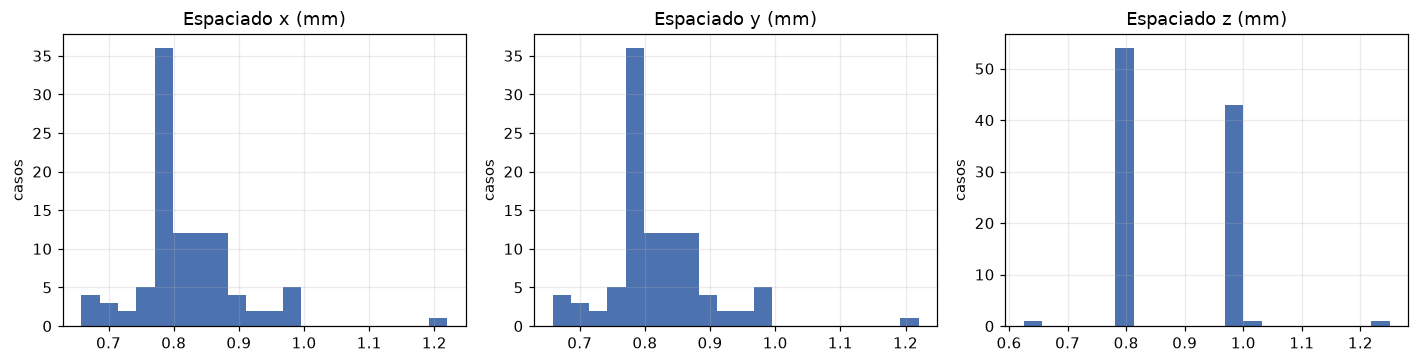

,dim_x,dim_y,dim_z,spacing_x,spacing_y,spacing_z
min,322.0,154.0,193.00,0.658,0.658,0.625
25%,508.0,299.5,285.75,0.781,0.781,0.800
50%,512.0,512.0,326.00,0.798,0.798,0.801
75%,512.0,512.0,350.00,0.858,0.858,1.000
max,512.0,512.0,414.00,1.220,1.220,1.250


In [8]:
fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))
for a, eje in zip(ax, "xyz"):
    a.hist(df[f"spacing_{eje}"], bins=20, color="#4c72b0")
    a.set_title(f"Espaciado {eje} (mm)"); a.set_ylabel("casos"); a.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig(OUT_DIR / "geometry_spacing.png", bbox_inches="tight", dpi=150)
plt.show()

df[["dim_x", "dim_y", "dim_z", "spacing_x", "spacing_y", "spacing_z"]].describe().round(3).loc[["min", "25%", "50%", "75%", "max"]]

### `ElementSpacing` frente a `ITK_original_spacing`

Solo las imágenes traen `ITK_original_spacing`; las máscaras traen únicamente `ElementSpacing`.

In [9]:
tol = 1e-3
print("Casos donde los dos campos difieren:", int(((abs(df.spacing_x - df.itk_orig_spacing_x) > tol) | (abs(df.spacing_y - df.itk_orig_spacing_y) > tol) | (abs(df.spacing_z - df.itk_orig_spacing_z) > tol)).sum()), "/", len(df))
for eje in "xyz":
    print(f"{eje} coincide en {int((abs(df[f'spacing_{eje}'] - df[f'itk_orig_spacing_{eje}']) < tol).sum())} casos")
print("ITK_original_spacing y == ElementSpacing z en:", int((abs(df.itk_orig_spacing_y - df.spacing_z) < tol).sum()), "casos")
print("ElementSpacing con x == y:", int((abs(df.spacing_x - df.spacing_y) < 1e-6).sum()), "casos | ITK_original_spacing con x == y:", int((abs(df.itk_orig_spacing_x - df.itk_orig_spacing_y) < tol).sum()), "casos")
df[["case_id", "spacing_x", "spacing_y", "spacing_z", "itk_orig_spacing_x", "itk_orig_spacing_y", "itk_orig_spacing_z"]].head(6).round(4)

Casos donde los dos campos difieren: 100 / 100
x coincide en 100 casos
y coincide en 0 casos
z coincide en 100 casos
ITK_original_spacing y == ElementSpacing z en: 100 casos
ElementSpacing con x == y: 100 casos | ITK_original_spacing con x == y: 0 casos


,case_id,spacing_x,spacing_y,spacing_z,itk_orig_spacing_x,itk_orig_spacing_y,itk_orig_spacing_z
0,001,0.7812,0.7812,0.8,0.7812,0.8,0.8
1,002,0.8242,0.8242,0.8,0.8242,0.8,0.8
2,003,0.7598,0.7598,1.0,0.7598,1.0,1.0
3,004,0.8438,0.8438,1.0,0.8438,1.0,1.0
4,005,0.8965,0.8965,1.0,0.8965,1.0,1.0
5,006,0.8125,0.8125,1.0,0.8125,1.0,1.0


### Orientación

`orientation` y `direction` describen cómo está almacenado el array respecto al paciente. La dirección identidad (`RAI` en el header) y la dirección diag(−1, −1, 1) (`LPI`) implican arrays volteados en x e y entre sí, es decir, un giro de 180° dentro del plano axial. La reorientación del pipeline lleva todos los volúmenes a la dirección identidad.

In [10]:
display(df.groupby(["orientation", "direction"]).size().rename("casos").reset_index())
for o in df.orientation.unique():
    print(f"{o}: {', '.join(df[df.orientation == o].case_id)}")
print("\nDirección tras el pipeline:", df.direction_pipeline.value_counts().to_dict())

,orientation,direction,casos
0,LPI,-1 0 0 0 -1 0 0 0 1,34
1,RAI,1 0 0 0 1 0 0 0 1,66


RAI: 001, 005, 007, 008, 010, 011, 012, 013, 015, 016, 017, 018, 019, 020, 021, 022, 024, 026, 027, 029, 030, 031, 032, 034, 037, 038, 039, 040, 042, 043, 046, 047, 048, 049, 051, 052, 053, 054, 055, 059, 061, 064, 065, 066, 068, 069, 070, 073, 074, 075, 076, 077, 080, 083, 084, 089, 090, 091, 092, 093, 094, 095, 096, 097, 098, 100
LPI: 002, 003, 004, 006, 009, 014, 023, 025, 028, 033, 035, 036, 041, 044, 045, 050, 056, 057, 058, 060, 062, 063, 067, 071, 072, 078, 079, 081, 082, 085, 086, 087, 088, 099

Dirección tras el pipeline: {'1 0 0 0 1 0 0 0 1': 100}


### Izquierda y derecha

Los códigos 11-20 se asignan al coxal izquierdo y los 21-30 al derecho. Se comprueba con dos criterios:

- **Coordenada física (LPS)**: la coordenada x crece hacia la izquierda del paciente, así que el coxal izquierdo debe tener mayor x que el derecho. No depende de cómo esté almacenado el array.
- **Posición en el array**: índice de columna del centroide de cada coxal, y fila del sacro respecto a los coxales. Se calcula antes y después de reorientar.

In [11]:
izq, der, sac = "left_hipbone", "right_hipbone", "sacrum"
df["izq_mayor_x_fisico"] = df[f"centroid_x_mm_{izq}"] > df[f"centroid_x_mm_{der}"]
df["sacro_entre_coxales_x"] = (df[f"centroid_x_mm_{sac}"] < df[f"centroid_x_mm_{izq}"]) & (df[f"centroid_x_mm_{sac}"] > df[f"centroid_x_mm_{der}"])
print(f"Coordenada física: coxal 11-20 con mayor x que 21-30 en {int(df.izq_mayor_x_fisico.sum())} / {len(df)} casos; sacro entre ambos en {int(df.sacro_entre_coxales_x.sum())} / {len(df)}\n")

# Posición en el array: antes (original) y después de reorientar
for sufijo, nombre in [("_original", "antes"), ("", "después")]:
    df[f"izq_mayor_columna_{nombre}"] = df[f"centroid_idx_x{sufijo}_{izq}"] > df[f"centroid_idx_x{sufijo}_{der}"]
    df[f"sacro_mayor_fila_{nombre}"] = df[f"centroid_idx_y{sufijo}_{sac}"] > (df[f"centroid_idx_y{sufijo}_{izq}"] + df[f"centroid_idx_y{sufijo}_{der}"]) / 2

resumen = df.groupby("orientation").agg(casos=("case_id", "size"),
    coxal_izq_en_columnas_mayores_antes=("izq_mayor_columna_antes", "sum"), sacro_en_filas_mayores_antes=("sacro_mayor_fila_antes", "sum"),
    coxal_izq_en_columnas_mayores_despues=("izq_mayor_columna_después", "sum"), sacro_en_filas_mayores_despues=("sacro_mayor_fila_después", "sum"))
resumen

Coordenada física: coxal 11-20 con mayor x que 21-30 en 100 / 100 casos; sacro entre ambos en 100 / 100



,casos,coxal_izq_en_columnas_mayores_antes,sacro_en_filas_mayores_antes,coxal_izq_en_columnas_mayores_despues,sacro_en_filas_mayores_despues
orientation,,,,,
LPI,34,0,0,34,34
RAI,66,66,66,66,66


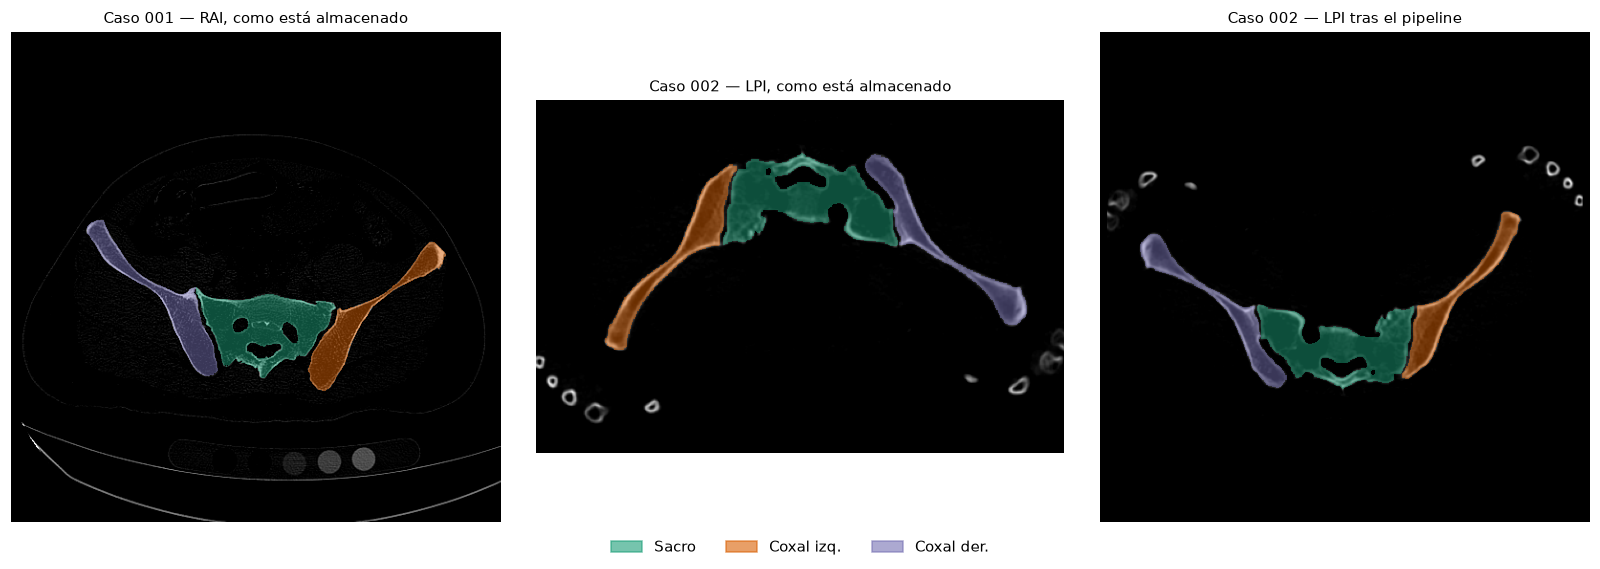

In [12]:
# Un caso RAI, un caso LPI y el mismo caso LPI tras el pipeline
c_rai, c_lpi = df[df.orientation == "RAI"].case_id.iloc[0], df[df.orientation == "LPI"].case_id.iloc[0]
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (c, pipeline, titulo) in zip(axes, [(c_rai, False, "RAI, como está almacenado"), (c_lpi, False, "LPI, como está almacenado"), (c_lpi, True, "LPI tras el pipeline")]):
    v_i, v_m = pre.load_volume(img_paths[c]), pre.load_volume(lbl_paths[c])
    if pipeline:
        r = pre.preprocess_volume(v_i, v_m); a_i, a_m = r["hu"], r["mask"]
    else:
        a_i, a_m = sitk.GetArrayFromImage(v_i), sitk.GetArrayFromImage(v_m)
    z = int((a_m > 0).reshape(a_m.shape[0], -1).sum(1).argmax())
    ax.imshow(np.clip(a_i[z], HU_LO, HU_HI), cmap="gray")
    ax.imshow(np.ma.masked_equal(lut[np.clip(a_m[z], 0, 255)], 0), cmap=cmap_reg, vmin=0, vmax=3, alpha=0.5, interpolation="nearest")
    ax.set_title(f"Caso {c} — {titulo}", fontsize=10); ax.axis("off")
fig.legend([plt.Rectangle((0, 0), 1, 1, color=COLOR_REGION[r], alpha=0.6) for r in REGION_ORDER], [NOMBRE_REGION[r] for r in REGION_ORDER],
           loc="lower center", ncol=3, frameon=False)
plt.tight_layout(rect=(0, 0.05, 1, 1))
plt.savefig(OUT_DIR / "orientation.png", bbox_inches="tight", dpi=150)
plt.show()

### Recorte

Efecto del recorte de `CROP_MM` mm sobre cada caso: tamaño resultante, fracción del recorte que es relleno (volumen más pequeño que el recorte) y hueso etiquetado que queda fuera del recorte.

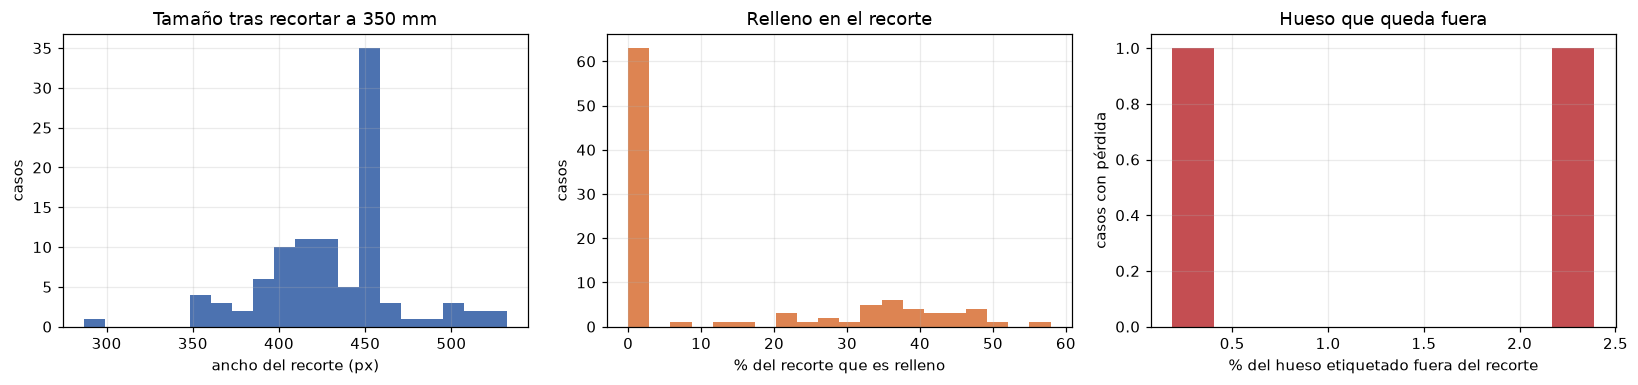

Casos con relleno: 38 | con más de 25 % de relleno: 31
Casos con hueso etiquetado fuera del recorte: 2 | fragmentos afectados: 4


,case_id,fov_x_mm,fov_y_mm,hueso_perdido_pct,frags_cortados_crop,fracture_type
15,016,400.0,400.0,2.39,2,BHF
29,030,395.0,395.0,0.19,2,BHF


In [13]:
df["hueso_perdido_pct"] = 100 * df.frac_hueso_perdido_crop
fig, ax = plt.subplots(1, 3, figsize=(15, 3.6))
ax[0].hist(df.crop_dim_x, bins=20, color="#4c72b0"); ax[0].set_xlabel("ancho del recorte (px)"); ax[0].set_ylabel("casos"); ax[0].set_title(f"Tamaño tras recortar a {CROP_MM[0]:.0f} mm")
ax[1].hist(100 * df.crop_pad_frac, bins=20, color="#dd8452"); ax[1].set_xlabel("% del recorte que es relleno"); ax[1].set_ylabel("casos"); ax[1].set_title("Relleno en el recorte")
ax[2].hist(df.hueso_perdido_pct[df.hueso_perdido_pct > 0], bins=10, color="#c44e52"); ax[2].set_xlabel("% del hueso etiquetado fuera del recorte"); ax[2].set_ylabel("casos con pérdida"); ax[2].set_title("Hueso que queda fuera")
for a in ax:
    a.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig(OUT_DIR / "crop_summary.png", bbox_inches="tight", dpi=150)
plt.show()

print(f"Casos con relleno: {(df.crop_pad_frac > 0).sum()} | con más de 25 % de relleno: {(df.crop_pad_frac > 0.25).sum()}")
print(f"Casos con hueso etiquetado fuera del recorte: {(df.frac_hueso_perdido_crop > 0).sum()} | fragmentos afectados: {int((df_frag.voxels_perdidos_crop > 0).sum())}")
df[df.frac_hueso_perdido_crop > 0][["case_id", "fov_x_mm", "fov_y_mm", "hueso_perdido_pct", "frags_cortados_crop", "fracture_type"]].round(2)

## Anisotropía

- **Anisotropía**: cociente máximo/mínimo de los tres espaciados de un caso (1 = vóxel cúbico).
- **Campo de visión**: dimensiones × espaciado, en mm.
- **mm por píxel a 256**: tamaño físico de un píxel en x si el corte completo se reduce a 256 píxeles de ancho. Con el recorte de `CROP_MM` es constante.

Los casos con anisotropía sobre `UMBRAL_ANISOTROPIA` quedan marcados en las figuras y en la tabla.

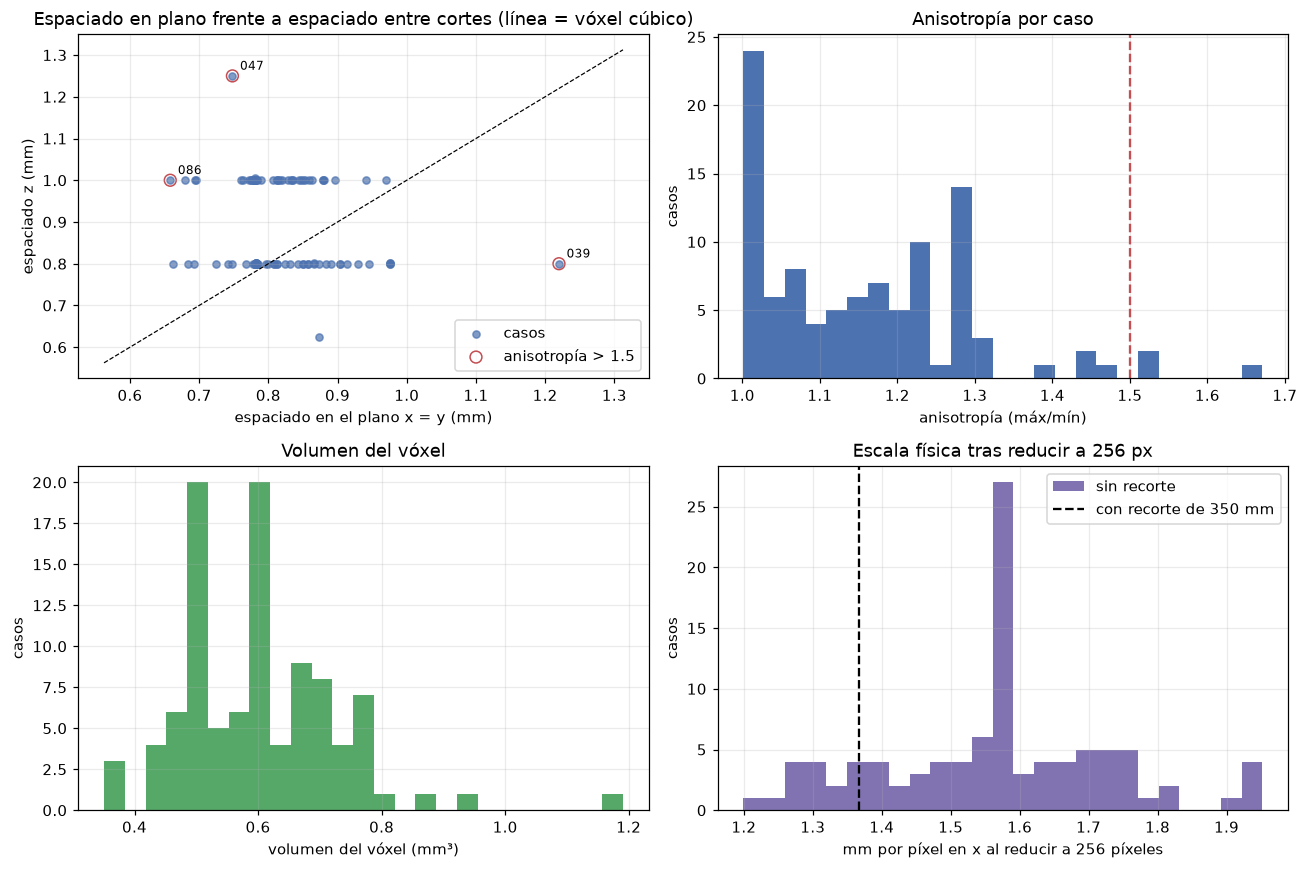

Anisotropía: mediana 1.15, máximo 1.67; casos sobre 1.5: 3
Espaciado x = y: 0.658 a 1.220 mm | z: 0.625 a 1.250 mm
Volumen de vóxel: 0.351 a 1.191 mm³ (cociente 3.4)
mm por píxel a 256 sin recorte: 1.199 a 1.952 (cociente 1.63); con recorte: 1.367
Campo de visión: x 307-500 mm, y 160-500 mm, z 224-353 mm


,case_id,dim_x,dim_y,dim_z,spacing_x,spacing_y,spacing_z,anisotropia,voxel_mm3,n_fragments,fracture_type
38,039,322,154,392,1.220,1.220,0.80,1.525,1.191,9,SHF
46,047,512,512,193,0.748,0.748,1.25,1.671,0.699,5,UHF
85,086,512,283,265,0.658,0.658,1.00,1.519,0.433,7,SHF


In [14]:
marcados = df[df.anisotropia > UMBRAL_ANISOTROPIA]
df["mm_por_px_256"] = df.fov_x_mm / 256

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
ax[0, 0].scatter(df.spacing_x, df.spacing_z, s=22, color="#4c72b0", alpha=0.7, label="casos")
ax[0, 0].scatter(marcados.spacing_x, marcados.spacing_z, s=60, facecolors="none", edgecolors="#c44e52", label=f"anisotropía > {UMBRAL_ANISOTROPIA}")
for _, r in marcados.iterrows():
    ax[0, 0].annotate(r.case_id, (r.spacing_x, r.spacing_z), textcoords="offset points", xytext=(5, 4), fontsize=8)
lim = [df[["spacing_x", "spacing_z"]].min().min() * 0.9, df[["spacing_x", "spacing_z"]].max().max() * 1.05]
ax[0, 0].plot(lim, lim, color="k", lw=0.8, ls="--")
ax[0, 0].set_xlabel("espaciado en el plano x = y (mm)"); ax[0, 0].set_ylabel("espaciado z (mm)")
ax[0, 0].set_title("Espaciado en plano frente a espaciado entre cortes (línea = vóxel cúbico)"); ax[0, 0].legend()
ax[0, 1].hist(df.anisotropia, bins=25, color="#4c72b0")
ax[0, 1].axvline(UMBRAL_ANISOTROPIA, color="#c44e52", ls="--"); ax[0, 1].set_xlabel("anisotropía (máx/mín)"); ax[0, 1].set_ylabel("casos"); ax[0, 1].set_title("Anisotropía por caso")
ax[1, 0].hist(df.voxel_mm3, bins=25, color="#55a868")
ax[1, 0].set_xlabel("volumen del vóxel (mm³)"); ax[1, 0].set_ylabel("casos"); ax[1, 0].set_title("Volumen del vóxel")
ax[1, 1].hist(df.mm_por_px_256, bins=25, color="#8172b2", label="sin recorte")
ax[1, 1].axvline(CROP_MM[0] / 256, color="k", ls="--", label=f"con recorte de {CROP_MM[0]:.0f} mm")
ax[1, 1].set_xlabel("mm por píxel en x al reducir a 256 píxeles"); ax[1, 1].set_ylabel("casos"); ax[1, 1].set_title("Escala física tras reducir a 256 px"); ax[1, 1].legend()
for a in ax.ravel():
    a.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig(OUT_DIR / "anisotropy.png", bbox_inches="tight", dpi=150)
plt.show()

print(f"Anisotropía: mediana {df.anisotropia.median():.2f}, máximo {df.anisotropia.max():.2f}; casos sobre {UMBRAL_ANISOTROPIA}: {len(marcados)}")
print(f"Espaciado x = y: {df.spacing_x.min():.3f} a {df.spacing_x.max():.3f} mm | z: {df.spacing_z.min():.3f} a {df.spacing_z.max():.3f} mm")
print(f"Volumen de vóxel: {df.voxel_mm3.min():.3f} a {df.voxel_mm3.max():.3f} mm³ (cociente {df.voxel_mm3.max() / df.voxel_mm3.min():.1f})")
print(f"mm por píxel a 256 sin recorte: {df.mm_por_px_256.min():.3f} a {df.mm_por_px_256.max():.3f} (cociente {df.mm_por_px_256.max() / df.mm_por_px_256.min():.2f}); con recorte: {CROP_MM[0] / 256:.3f}")
print(f"Campo de visión: x {df.fov_x_mm.min():.0f}-{df.fov_x_mm.max():.0f} mm, y {df.fov_y_mm.min():.0f}-{df.fov_y_mm.max():.0f} mm, z {df.fov_z_mm.min():.0f}-{df.fov_z_mm.max():.0f} mm")
marcados[["case_id", "dim_x", "dim_y", "dim_z", "spacing_x", "spacing_y", "spacing_z", "anisotropia", "voxel_mm3", "n_fragments", "fracture_type"]].round(3)

In [15]:
# Longitud en mm de 10 vóxeles en cada eje, y error si se ignora el espaciado
efecto = df[["case_id", "spacing_x", "spacing_y", "spacing_z"]].copy()
efecto[["10 vóx en x (mm)", "10 vóx en y (mm)", "10 vóx en z (mm)"]] = 10 * esp.to_numpy()
efecto["error si se ignora el espaciado (mm)"] = 10 * (esp.max(axis=1) - esp.min(axis=1))
efecto.set_index("case_id").loc[list(marcados.case_id) + ["001"]].round(2)

,spacing_x,spacing_y,spacing_z,10 vóx en x (mm),10 vóx en y (mm),10 vóx en z (mm),error si se ignora el espaciado (mm)
case_id,,,,,,,
039,1.22,1.22,0.80,12.20,12.20,8.0,4.20
047,0.75,0.75,1.25,7.48,7.48,12.5,5.02
086,0.66,0.66,1.00,6.58,6.58,10.0,3.42
001,0.78,0.78,0.80,7.81,7.81,8.0,0.19


## Intensidades HU

### Ventaneo

Corte axial central del caso `CASE_ID` (tras reorientar y recortar) sin ventana, con ventana de partes blandas y con la ventana `[HU_LO, HU_HI]`.

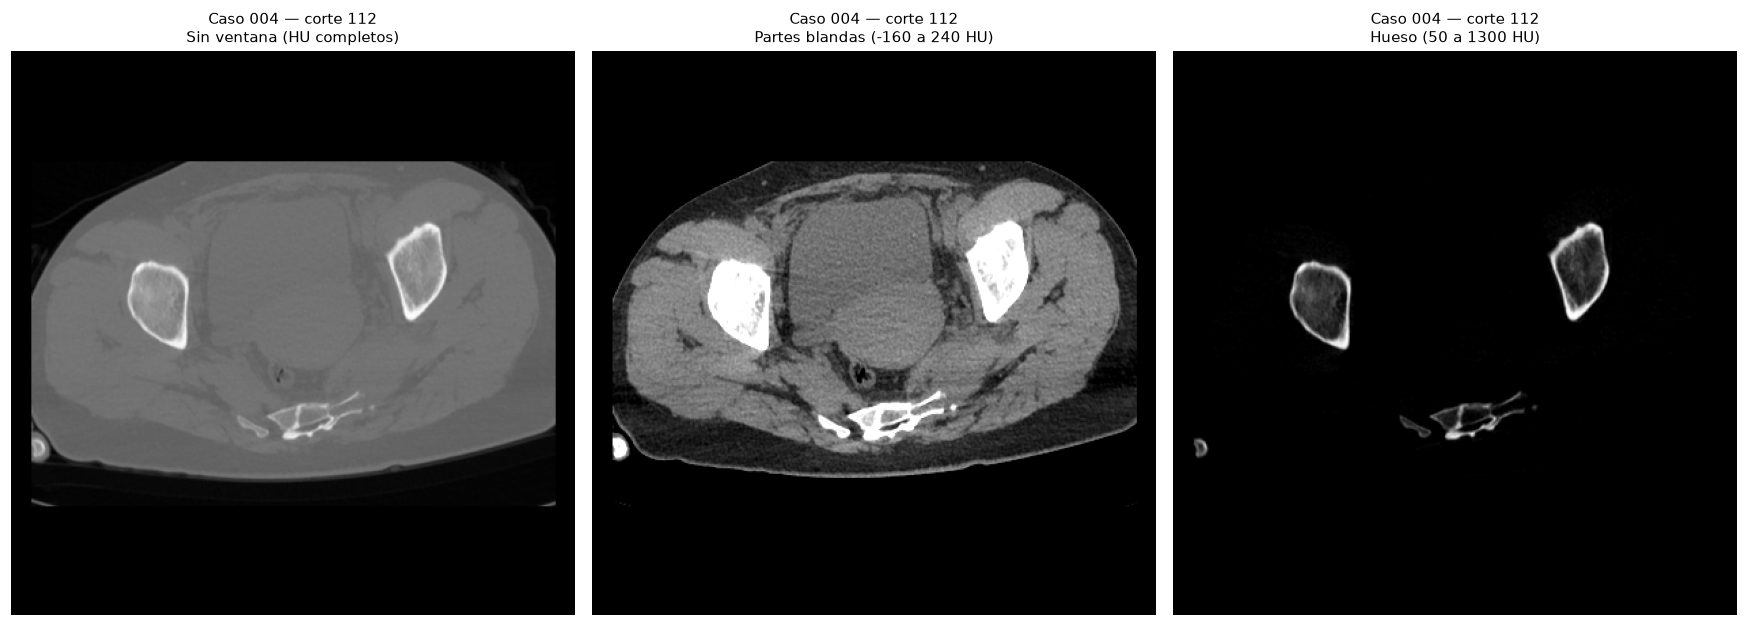

In [16]:
corte = img.shape[0] // 2
ventanas = {
    "Sin ventana (HU completos)": None,
    "Partes blandas (-160 a 240 HU)": (-160, 240),
    f"Hueso ({HU_LO:.0f} a {HU_HI:.0f} HU)": (HU_LO, HU_HI),
}
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
for ax, (nombre, v) in zip(axes, ventanas.items()):
    ax.imshow(img[corte] if v is None else np.clip(img[corte], v[0], v[1]), cmap="gray")
    ax.set_title(f"Caso {CASE_ID} — corte {corte}\n{nombre}", fontsize=10); ax.axis("off")
plt.tight_layout()
plt.show()

### Histograma HU

Histograma acumulado de los 100 casos (1 HU por bin), de todo el volumen reorientado y solo de los vóxeles etiquetados como hueso. La banda azul es la ventana `[HU_LO, HU_HI]`.

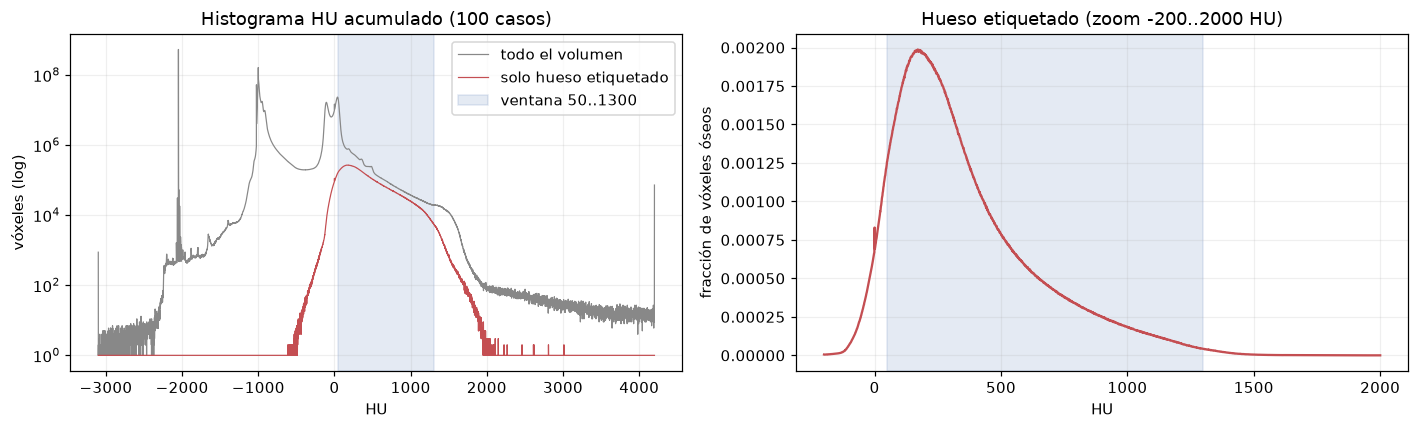

In [17]:
h_todo, h_hueso = H_todo.sum(axis=0), H_hueso.sum(axis=0)

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].semilogy(bins_hu, np.clip(h_todo, 1, None), color="#888", lw=0.8, label="todo el volumen")
ax[0].semilogy(bins_hu, np.clip(h_hueso, 1, None), color="#c44e52", lw=0.8, label="solo hueso etiquetado")
ax[0].axvspan(HU_LO, HU_HI, color="#4c72b0", alpha=0.15, label=f"ventana {HU_LO:.0f}..{HU_HI:.0f}")
ax[0].set_xlabel("HU"); ax[0].set_ylabel("vóxeles (log)"); ax[0].legend()
ax[0].set_title(f"Histograma HU acumulado ({len(df)} casos)"); ax[0].grid(True, alpha=0.2)
zoom = (bins_hu >= -200) & (bins_hu <= 2000)
ax[1].plot(bins_hu[zoom], h_hueso[zoom] / h_hueso.sum(), color="#c44e52")
ax[1].axvspan(HU_LO, HU_HI, color="#4c72b0", alpha=0.15)
ax[1].set_xlabel("HU"); ax[1].set_ylabel("fracción de vóxeles óseos")
ax[1].set_title("Hueso etiquetado (zoom -200..2000 HU)"); ax[1].grid(True, alpha=0.2)
plt.tight_layout()
plt.savefig(OUT_DIR / "hu_histogram.png", bbox_inches="tight", dpi=150)
plt.show()

Percentiles HU del hueso etiquetado (todos los casos): {0.001: -128, 0.01: -50, 0.05: 21, 0.5: 283, 0.95: 935, 0.99: 1205, 0.999: 1433}
Vóxeles óseos dentro de [50, 1300]: 91.4% | por debajo de 50: 8.1% | por encima de 1300: 0.4%
HU mínimo < -1100: 35 casos | HU máximo > 3100: 40 casos | HU máximo > 10000: 16 casos
Valores mínimos más frecuentes (relleno fuera del campo de visión): {-1023: 58, -2048: 23, -1024: 5, -1418: 1}


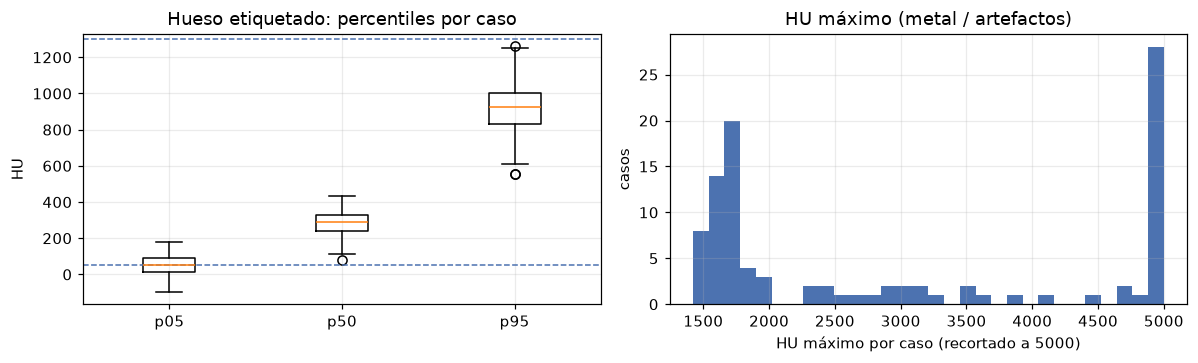

In [18]:
cum_h = np.cumsum(h_hueso) / h_hueso.sum()
print("Percentiles HU del hueso etiquetado (todos los casos):",
      {p: int(bins_hu[np.searchsorted(cum_h, p)]) for p in (0.001, 0.01, 0.05, 0.5, 0.95, 0.99, 0.999)})
dentro = h_hueso[(bins_hu >= HU_LO) & (bins_hu <= HU_HI)].sum() / h_hueso.sum()
bajo, sobre = h_hueso[bins_hu < HU_LO].sum() / h_hueso.sum(), h_hueso[bins_hu > HU_HI].sum() / h_hueso.sum()
print(f"Vóxeles óseos dentro de [{HU_LO:.0f}, {HU_HI:.0f}]: {dentro:.1%} | por debajo de {HU_LO:.0f}: {bajo:.1%} | por encima de {HU_HI:.0f}: {sobre:.1%}")
print(f"HU mínimo < -1100: {(df.hu_min < -1100).sum()} casos | HU máximo > 3100: {(df.hu_max > 3100).sum()} casos | HU máximo > 10000: {(df.hu_max > 10000).sum()} casos")
print("Valores mínimos más frecuentes (relleno fuera del campo de visión):", df.hu_min.value_counts().head(4).to_dict())

fig, ax = plt.subplots(1, 2, figsize=(11, 3.4))
ax[0].boxplot([df.bone_hu_p05, df.bone_hu_p50, df.bone_hu_p95], tick_labels=["p05", "p50", "p95"])
ax[0].axhline(HU_LO, color="#4c72b0", ls="--", lw=1); ax[0].axhline(HU_HI, color="#4c72b0", ls="--", lw=1)
ax[0].set_ylabel("HU"); ax[0].set_title("Hueso etiquetado: percentiles por caso"); ax[0].grid(True, alpha=0.25)
ax[1].hist(df.hu_max.clip(upper=5000), bins=30, color="#4c72b0")
ax[1].set_xlabel("HU máximo por caso (recortado a 5000)"); ax[1].set_ylabel("casos"); ax[1].set_title("HU máximo (metal / artefactos)"); ax[1].grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig(OUT_DIR / "hu_per_case.png", bbox_inches="tight", dpi=150)
plt.show()

### Hueso etiquetado por debajo de la ventana

Fracción de vóxeles etiquetados con HU menor que `HU_LO` en cada caso: quedan en 0 tras el ventaneo.

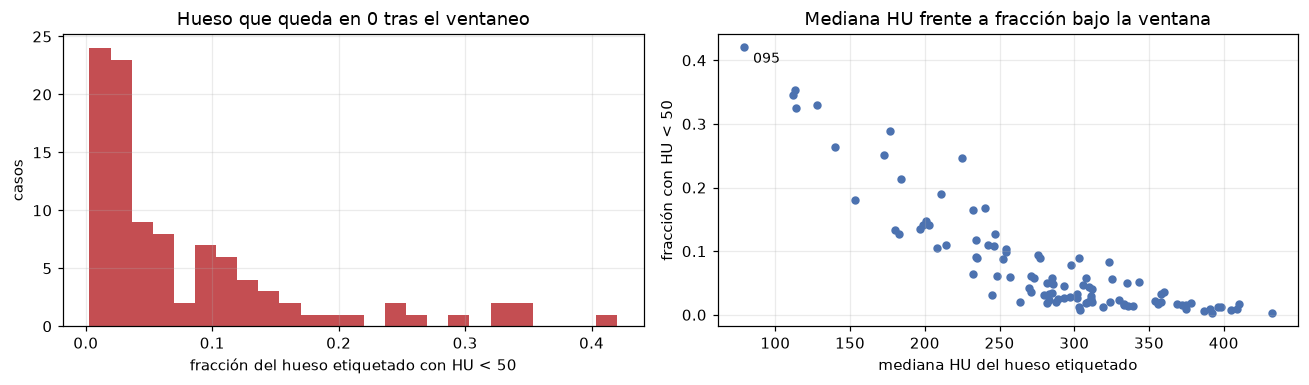

Fracción media del hueso etiquetado con HU < 50: 8.0% (mediana 4.5%, máximo 42.0%)


,case_id,bone_hu_p05,bone_hu_p50,bone_hu_p95,frac_hueso_bajo_HU_LO
94,095,-63,79,553,0.420
26,027,-64,113,654,0.353
33,034,-60,112,553,0.346
12,013,-74,128,698,0.330
25,026,-37,114,610,0.325
72,073,-47,177,861,0.289
24,025,-33,140,666,0.264
0,001,-97,173,1124,0.252


In [19]:
df["frac_hueso_bajo_HU_LO"] = H_hueso[:, bins_hu < HU_LO].sum(axis=1) / H_hueso.sum(axis=1)
df["frac_hueso_sobre_HU_HI"] = H_hueso[:, bins_hu > HU_HI].sum(axis=1) / H_hueso.sum(axis=1)

fig, ax = plt.subplots(1, 2, figsize=(12, 3.6))
ax[0].hist(df.frac_hueso_bajo_HU_LO, bins=25, color="#c44e52")
ax[0].set_xlabel(f"fracción del hueso etiquetado con HU < {HU_LO:.0f}"); ax[0].set_ylabel("casos"); ax[0].set_title("Hueso que queda en 0 tras el ventaneo")
ax[1].scatter(df.bone_hu_p50, df.frac_hueso_bajo_HU_LO, s=20, color="#4c72b0")
r = df[df.case_id == CASO_HU_BAJO].iloc[0]
ax[1].annotate(CASO_HU_BAJO, (r.bone_hu_p50, r.frac_hueso_bajo_HU_LO), textcoords="offset points", xytext=(6, -10), fontsize=9)
ax[1].set_xlabel("mediana HU del hueso etiquetado"); ax[1].set_ylabel(f"fracción con HU < {HU_LO:.0f}"); ax[1].set_title("Mediana HU frente a fracción bajo la ventana")
for a in ax:
    a.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig(OUT_DIR / "hu_bajo_ventana.png", bbox_inches="tight", dpi=150)
plt.show()

print(f"Fracción media del hueso etiquetado con HU < {HU_LO:.0f}: {df.frac_hueso_bajo_HU_LO.mean():.1%} (mediana {df.frac_hueso_bajo_HU_LO.median():.1%}, máximo {df.frac_hueso_bajo_HU_LO.max():.1%})")
df.sort_values("frac_hueso_bajo_HU_LO", ascending=False)[["case_id", "bone_hu_p05", "bone_hu_p50", "bone_hu_p95", "frac_hueso_bajo_HU_LO"]].head(8).round(3)

### Compromiso del límite inferior de la ventana

Para cada límite inferior de `LIMITES_INFERIORES_HU` (con `HU_HI` como límite superior):

- **hueso etiquetado por debajo**: fracción de vóxeles etiquetados que quedan en 0.
- **no etiquetado dentro**: fracción de los vóxeles dentro de la ventana que no están etiquetados (tejido blando y también hueso fuera de la máscara, como fémur o vértebras lumbares).
- Las mismas fracciones de hueso por debajo para el caso `CASO_HU_BAJO` y la mediana de casos.

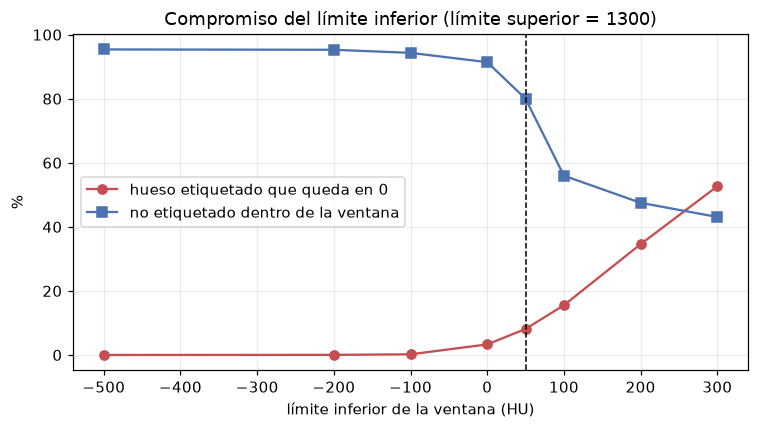

,hueso etiquetado por debajo,no etiquetado dentro de la ventana,caso 095: hueso por debajo,mediana de casos: hueso por debajo
limite_inferior_HU,,,,
-500,0.0,95.4,0.0,0.0
-200,0.0,95.3,0.0,0.0
-100,0.2,94.3,0.8,0.0
0,3.3,91.4,25.4,1.2
50,8.1,80.0,42.0,4.5
100,15.5,56.0,54.8,11.2
200,34.6,47.5,72.0,31.8
300,52.7,43.1,83.1,52.3


In [20]:
no_hueso = h_todo - h_hueso
filas_lim = []
for lo in LIMITES_INFERIORES_HU:
    en_ventana = (bins_hu >= lo) & (bins_hu <= HU_HI)
    por_caso = H_hueso[:, bins_hu < lo].sum(axis=1) / H_hueso.sum(axis=1)
    filas_lim.append({"limite_inferior_HU": lo,
                      "hueso etiquetado por debajo": h_hueso[bins_hu < lo].sum() / h_hueso.sum(),
                      "no etiquetado dentro de la ventana": no_hueso[en_ventana].sum() / h_todo[en_ventana].sum(),
                      f"caso {CASO_HU_BAJO}: hueso por debajo": por_caso[list(df.case_id).index(CASO_HU_BAJO)],
                      "mediana de casos: hueso por debajo": np.median(por_caso)})
tab_lim = pd.DataFrame(filas_lim).set_index("limite_inferior_HU")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(tab_lim.index, 100 * tab_lim["hueso etiquetado por debajo"], "o-", color="#c44e52", label="hueso etiquetado que queda en 0")
ax.plot(tab_lim.index, 100 * tab_lim["no etiquetado dentro de la ventana"], "s-", color="#4c72b0", label="no etiquetado dentro de la ventana")
ax.axvline(HU_LO, color="k", ls="--", lw=1)
ax.set_xlabel("límite inferior de la ventana (HU)"); ax.set_ylabel("%"); ax.set_title(f"Compromiso del límite inferior (límite superior = {HU_HI:.0f})")
ax.legend(); ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig(OUT_DIR / "hu_window_tradeoff.png", bbox_inches="tight", dpi=150)
plt.show()
(tab_lim * 100).round(1)

### HU óseo bajo: análisis de un caso

Para `CASO_HU_BAJO` se comparan, contra casos de referencia (los de menor mediana y los más cercanos a la mediana del dataset):

1. Distribución de HU dentro de la máscara.
2. Picos de grasa y de músculo del volumen completo (referencia de calibración del escáner).
3. Mediana HU dentro de la máscara completa, de su interior (erosionada 2 vóxeles) y de su borde.
4. Mediana HU por región anatómica.

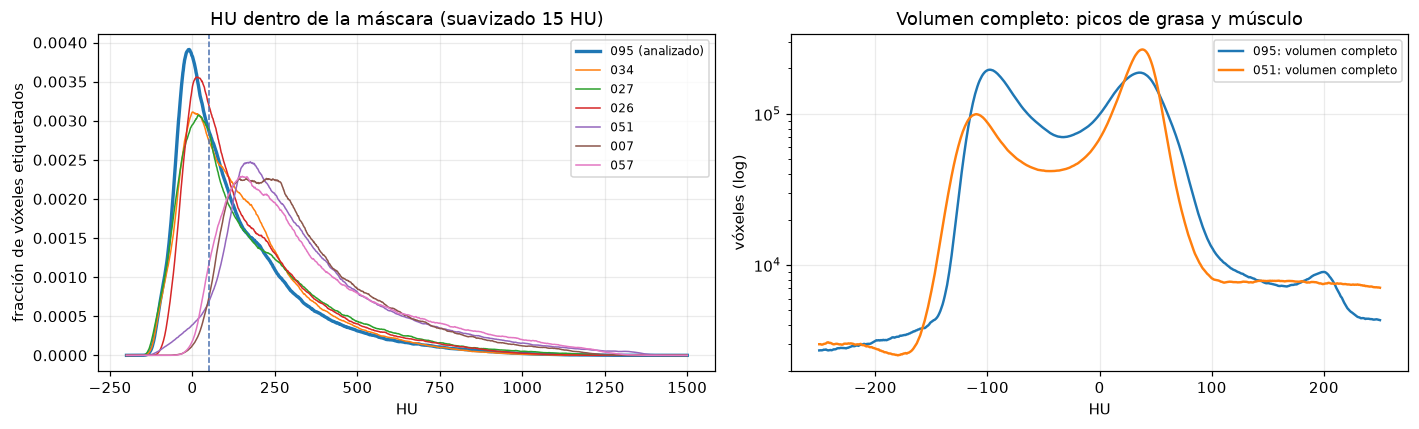

Mediana HU del hueso etiquetado en el dataset: 287 | pico de grasa (mediana de casos): -104 HU | pico de músculo: 38 HU


,mediana_mascara,mediana_interior,mediana_borde,frac_interior,mediana_sacrum,mediana_left_hipbone,mediana_right_hipbone,pico_grasa_HU,pico_musculo_HU,frac_hueso_bajo_HU_LO
case_id,,,,,,,,,,
095,79.0,24.0,247.0,0.64,49.0,90.0,85.0,-98,35,0.42
034,112.0,40.0,235.0,0.58,61.0,136.0,123.0,-40,22,0.35
027,113.0,41.0,292.0,0.61,58.0,130.0,140.0,-111,32,0.35
026,114.0,50.0,278.0,0.61,82.0,125.0,128.0,-95,32,0.32
051,286.0,216.0,465.0,0.65,211.0,307.0,315.0,-109,38,0.05
007,288.0,221.0,437.0,0.64,242.0,296.0,310.0,-92,47,0.02
057,285.0,202.0,487.0,0.60,222.0,313.0,308.0,-107,40,0.03


In [21]:
otros_bajos = df[df.case_id != CASO_HU_BAJO].nsmallest(3, "bone_hu_p50").case_id.tolist()
mediana_ds = df.bone_hu_p50.median()
resto = df[~df.case_id.isin([CASO_HU_BAJO, *otros_bajos])]
cercanos = resto.iloc[np.argsort((resto.bone_hu_p50 - mediana_ds).abs().to_numpy())[:3]].case_id.tolist()
casos_cmp = [CASO_HU_BAJO] + otros_bajos + cercanos
idx = {c: k for k, c in enumerate(df.case_id)}

rango_grasa = (bins_hu >= -150) & (bins_hu <= -40)
rango_musculo = (bins_hu >= 0) & (bins_hu <= 80)
df["pico_grasa_HU"] = bins_hu[rango_grasa][H_todo[:, rango_grasa].argmax(axis=1)]
df["pico_musculo_HU"] = bins_hu[rango_musculo][H_todo[:, rango_musculo].argmax(axis=1)]

filas_cmp = []
for c in casos_cmp:
    r = pre.preprocess_file(img_paths[c], lbl_paths[c])
    a_i, a_m = r["hu"], r["mask"]
    ejes = np.argwhere(a_m > 0)
    z0, y0, x0 = ejes.min(0); z1, y1, x1 = ejes.max(0) + 1
    r_m, r_i = a_m[z0:z1, y0:y1, x0:x1], a_i[z0:z1, y0:y1, x0:x1]
    interior = sitk.GetArrayFromImage(sitk.BinaryErode(sitk.GetImageFromArray((r_m > 0).astype(np.uint8)), [2, 2, 2])).astype(bool)
    borde = (r_m > 0) & ~interior
    fila = {"case_id": c, "mediana_mascara": np.median(r_i[r_m > 0]), "mediana_interior": np.median(r_i[interior]),
            "mediana_borde": np.median(r_i[borde]), "frac_interior": interior.sum() / (r_m > 0).sum()}
    for reg, cods in REGIONES.items():
        sel = np.isin(a_m, list(cods))
        fila[f"mediana_{reg}"] = np.median(a_i[sel]) if sel.any() else np.nan
    filas_cmp.append(fila)
tab_cmp = pd.DataFrame(filas_cmp).set_index("case_id")
for col in ("pico_grasa_HU", "pico_musculo_HU", "frac_hueso_bajo_HU_LO"):
    tab_cmp[col] = df.set_index("case_id").loc[casos_cmp, col]

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
zoom = (bins_hu >= -200) & (bins_hu <= 1500)
for c in casos_cmp:
    hb = H_hueso[idx[c]]
    ax[0].plot(bins_hu[zoom], np.convolve(hb, np.ones(15) / 15, mode="same")[zoom] / hb.sum(),
               lw=2.2 if c == CASO_HU_BAJO else 1, label=c + (" (analizado)" if c == CASO_HU_BAJO else ""))
ax[0].axvline(HU_LO, color="#4c72b0", ls="--", lw=1)
ax[0].set_xlabel("HU"); ax[0].set_ylabel("fracción de vóxeles etiquetados"); ax[0].set_title("HU dentro de la máscara (suavizado 15 HU)"); ax[0].legend(fontsize=8)
zoom2 = (bins_hu >= -250) & (bins_hu <= 250)
for c in [CASO_HU_BAJO, cercanos[0]]:
    ax[1].semilogy(bins_hu[zoom2], np.convolve(H_todo[idx[c]], np.ones(5) / 5, mode="same")[zoom2], lw=1.6, label=f"{c}: volumen completo")
ax[1].set_xlabel("HU"); ax[1].set_ylabel("vóxeles (log)"); ax[1].set_title("Volumen completo: picos de grasa y músculo"); ax[1].legend(fontsize=8)
for a in ax:
    a.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig(OUT_DIR / "hu_caso_bajo.png", bbox_inches="tight", dpi=150)
plt.show()

print(f"Mediana HU del hueso etiquetado en el dataset: {mediana_ds:.0f} | pico de grasa (mediana de casos): {df.pico_grasa_HU.median():.0f} HU | pico de músculo: {df.pico_musculo_HU.median():.0f} HU")
tab_cmp.round(2)

## Fragmentos

### Inspección de las máscaras de un caso

Cada valor entero > 0 de la máscara identifica un **fragmento óseo individual**. La taxonomía consolida 3 regiones anatómicas (sacro, hueso coxal izquierdo y derecho); cada región puede tener hasta 10 fragmentos cuando hay fractura. Para `CASE_ID` se muestran los códigos presentes, su volumen en mm³ (vóxeles × volumen del vóxel) y en cuántos cortes axiales aparece cada uno.

In [22]:
fragmentos, conteos = np.unique(msk[msk > 0], return_counts=True)
vox_mm3 = float(np.prod(res["spacing"]))

df_frag_caso = pd.DataFrame({"fragmento_id": fragmentos, "voxels": conteos})
df_frag_caso["volumen_mm3"] = (df_frag_caso["voxels"] * vox_mm3).round(0).astype(int)
df_frag_caso["cortes_axiales"] = [int((msk == f).any(axis=(1, 2)).sum()) for f in fragmentos]
print(f"Caso {CASE_ID}: {len(fragmentos)} fragmentos etiquetados (IDs {fragmentos.min()}–{fragmentos.max()})")
df_frag_caso

Caso 004: 6 fragmentos etiquetados (IDs 1–22)


,fragmento_id,voxels,volumen_mm3,cortes_axiales
0,1,167936,119556,137
1,2,42193,30038,69
2,11,287370,204583,174
3,12,28827,20522,72
4,21,300663,214046,182
5,22,14254,10148,36


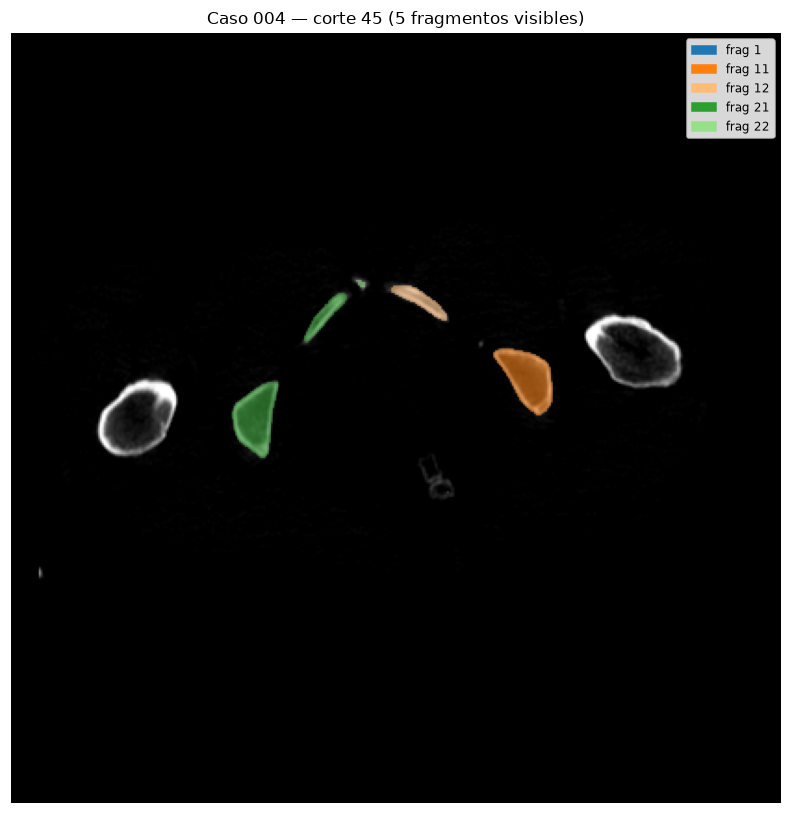

In [23]:
# Corte con mayor número de fragmentos distintos
n_frag_por_corte = np.zeros(msk.shape[0], dtype=int)
for f in fragmentos:
    n_frag_por_corte += (msk == f).any(axis=(1, 2)).astype(int)
mejor_corte = int(n_frag_por_corte.argmax())

fig, ax = plt.subplots(figsize=(7.5, 7.5))
ax.imshow(np.clip(img[mejor_corte], HU_LO, HU_HI), cmap="gray")
cmap = plt.get_cmap("tab20")
handles = []
for k, f in enumerate(fragmentos):
    sel = msk[mejor_corte] == f
    if not sel.any():
        continue
    color = cmap(k % 20)
    rgba = np.zeros((*sel.shape, 4), dtype=float)
    rgba[..., :3] = color[:3]
    rgba[..., 3] = 0.55 * sel
    ax.imshow(rgba)
    handles.append(mpatches.Patch(color=color, label=f"frag {f}"))
ax.legend(handles=handles, loc="upper right", fontsize=8, framealpha=0.85)
ax.set_title(f"Caso {CASE_ID} — corte {mejor_corte} ({n_frag_por_corte[mejor_corte]} fragmentos visibles)", fontsize=11)
ax.axis("off")
plt.tight_layout()
plt.show()

### Fragmentos por caso y por región

Número de fragmentos por caso y por región anatómica, volumen por fragmento y relación entre el código del fragmento y su tamaño.

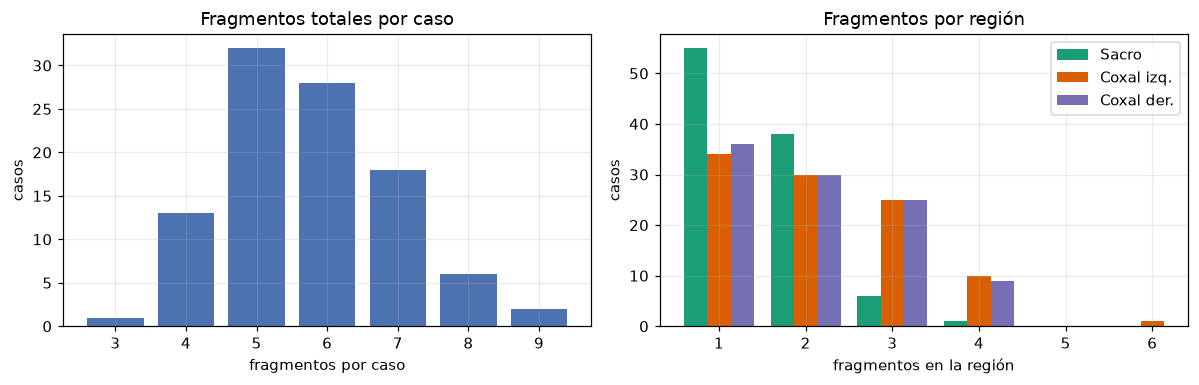

Total por caso: media 5.75, mediana 6, rango 3-9


,Sacro,Coxal izq.,Coxal der.
mean,1.53,2.15,2.07
min,1.00,1.00,1.00
max,4.00,6.00,4.00


In [24]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
vc = df.n_fragments.value_counts().sort_index()
ax[0].bar(vc.index, vc.values, color="#4c72b0")
ax[0].set_xlabel("fragmentos por caso"); ax[0].set_ylabel("casos"); ax[0].set_title("Fragmentos totales por caso")
w = 0.27
for k, r in enumerate(REGION_ORDER):
    v = df[f"n_frag_{r}"].value_counts().sort_index()
    ax[1].bar(v.index + (k - 1) * w, v.values, width=w, color=COLOR_REGION[r], label=NOMBRE_REGION[r])
ax[1].set_xlabel("fragmentos en la región"); ax[1].set_ylabel("casos"); ax[1].set_title("Fragmentos por región"); ax[1].legend()
for a in ax:
    a.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig(OUT_DIR / "fragments_per_case.png", bbox_inches="tight", dpi=150)
plt.show()

print(f"Total por caso: media {df.n_fragments.mean():.2f}, mediana {df.n_fragments.median():.0f}, rango {df.n_fragments.min()}-{df.n_fragments.max()}")
tab = df[[f"n_frag_{r}" for r in REGION_ORDER]].describe().round(2).loc[["mean", "min", "max"]]
tab.columns = [NOMBRE_REGION[r] for r in REGION_ORDER]
tab

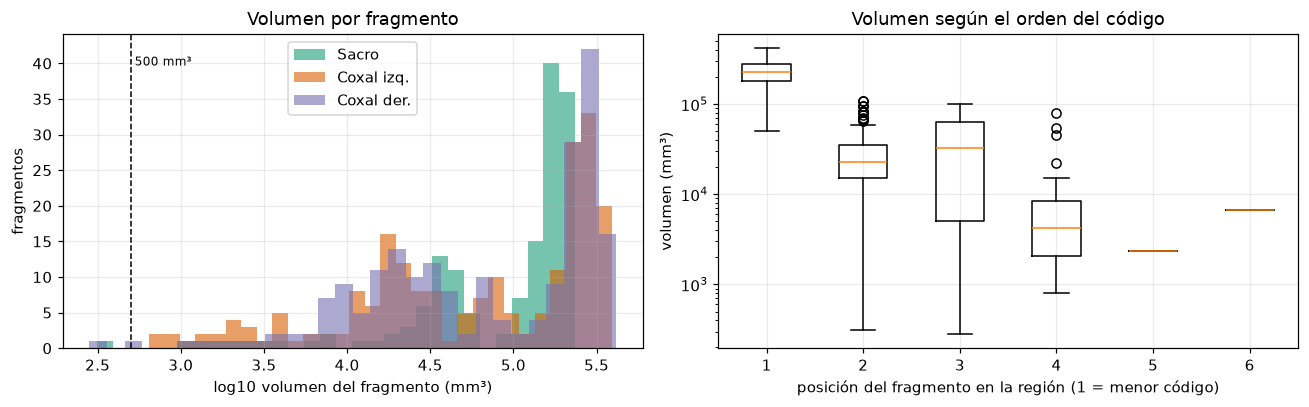

In [25]:
fr = df_frag.copy()
fr["rank"] = fr.groupby(["case_id", "region"]).code.rank().astype(int)   # posición dentro de la región (1 = menor código)

fig, ax = plt.subplots(1, 2, figsize=(12, 3.8))
for r in REGION_ORDER:
    ax[0].hist(np.log10(fr[fr.region == r].volume_mm3), bins=30, alpha=0.6, color=COLOR_REGION[r], label=NOMBRE_REGION[r])
ax[0].axvline(np.log10(UMBRAL_FRAGMENTO_MM3), color="k", ls="--", lw=1)
ax[0].text(np.log10(UMBRAL_FRAGMENTO_MM3), ax[0].get_ylim()[1] * 0.9, f" {UMBRAL_FRAGMENTO_MM3} mm³", fontsize=8)
ax[0].set_xlabel("log10 volumen del fragmento (mm³)"); ax[0].set_ylabel("fragmentos"); ax[0].legend(); ax[0].set_title("Volumen por fragmento")
datos = [fr[fr["rank"] == k].volume_mm3 for k in range(1, 9) if (fr["rank"] == k).any()]
ax[1].boxplot(datos, tick_labels=range(1, len(datos) + 1)); ax[1].set_yscale("log")
ax[1].set_xlabel("posición del fragmento en la región (1 = menor código)"); ax[1].set_ylabel("volumen (mm³)"); ax[1].set_title("Volumen según el orden del código")
for a in ax:
    a.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig(OUT_DIR / "fragment_volumes.png", bbox_inches="tight", dpi=150)
plt.show()

#### Fragmento principal de cada región

Se comprueba si el fragmento de mayor volumen de cada región es el de menor código, y si el resto de códigos sigue el orden de volumen.

In [26]:
for r in REGION_ORDER:
    m = df[df[f"n_frag_{r}"] > 1]
    print(f"{NOMBRE_REGION[r]:11s}: {len(m):3d} casos con >1 fragmento | fragmento mayor = menor código en {int(m[f'main_is_first_code_{r}'].sum())} | códigos ordenados por volumen en {int(m[f'codes_sorted_by_volume_{r}'].sum())}")

Sacro      :  45 casos con >1 fragmento | fragmento mayor = menor código en 45 | códigos ordenados por volumen en 41
Coxal izq. :  66 casos con >1 fragmento | fragmento mayor = menor código en 66 | códigos ordenados por volumen en 44
Coxal der. :  64 casos con >1 fragmento | fragmento mayor = menor código en 64 | códigos ordenados por volumen en 45


### Tipo de fractura derivado

Conteo de casos por tipo de fractura derivado del número de fragmentos por región.

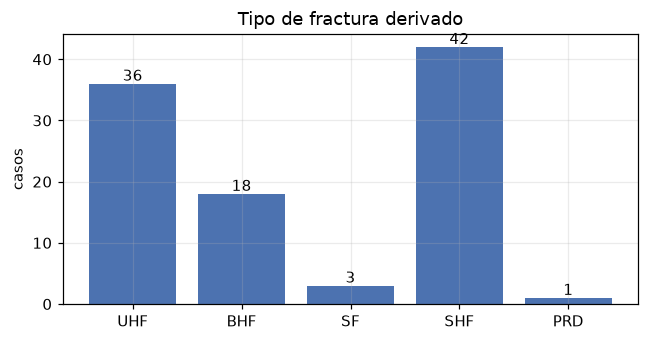

fracture_type,UHF,BHF,SF,SHF,PRD
casos,36,18,3,42,1


Casos SF: 019, 063, 080
Casos PRD: 022


In [27]:
orden_tipos = ["UHF", "BHF", "SF", "SHF", "PRD"]
ft = df.fracture_type.value_counts().reindex(orden_tipos).fillna(0).astype(int)
fig, ax = plt.subplots(figsize=(6, 3.2))
ax.bar(ft.index, ft.values, color="#4c72b0")
for k, v in enumerate(ft.values):
    ax.text(k, v + 0.5, str(v), ha="center")
ax.set_ylabel("casos"); ax.set_title("Tipo de fractura derivado"); ax.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig(OUT_DIR / "fracture_types.png", bbox_inches="tight", dpi=150)
plt.show()
display(ft.rename("casos").to_frame().T)
for t in ("SF", "PRD"):
    print(f"Casos {t}:", ", ".join(df[df.fracture_type == t].case_id))

### Conectividad de los fragmentos

Cada fragmento debería ser una sola componente conexa. Se cuentan las componentes con dos definiciones de vecindad:

- **6 vecinos**: dos vóxeles son vecinos si comparten una cara.
- **26 vecinos**: también si comparten una arista o un vértice (contacto diagonal).

Un fragmento con más componentes bajo 6 vecinos que bajo 26 tiene piezas unidas solo por contacto diagonal. Un fragmento con varias componentes también bajo 26 vecinos tiene piezas realmente separadas.

Fragmentos totales: 575
Con más de una componente (6 vecinos) : 136 (24%), en 75 casos
Con más de una componente (26 vecinos): 108 (19%), en 68 casos
Componentes secundarias (6 vecinos): 290, mediana 2 vóxeles, máximo 3222
Componentes secundarias (26 vecinos): 166, mediana 28 vóxeles, máximo 3222


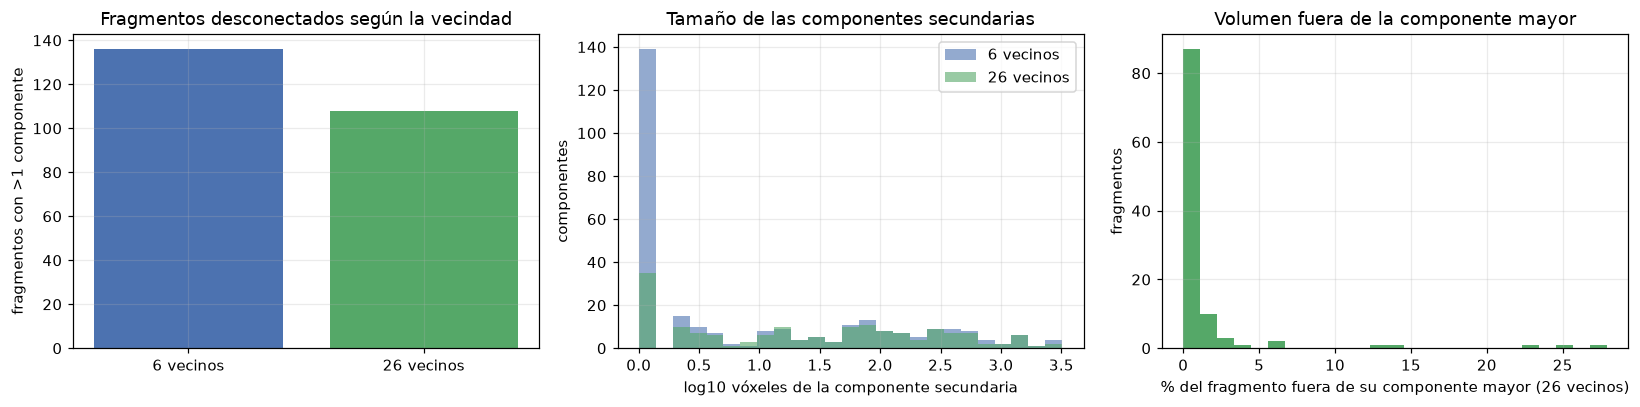

,case_id,code,region,volume_mm3,n_components_6,n_components_26,largest_component_frac_26,comp_sizes_26
122,023,12,left_hipbone,807.296,2,2,0.721,1204;466
365,064,2,sacrum,8021.722,5,5,0.754,12344;3219;360;304;149
361,063,3,sacrum,3966.479,5,5,0.766,4670;1128;221;60;17
232,041,2,sacrum,6267.877,7,4,0.859,11008;1255;546;3
253,045,2,sacrum,2334.479,6,5,0.869,2747;250;69;55;40
451,079,13,left_hipbone,5021.405,2,2,0.935,9769;676
474,084,2,sacrum,38650.713,5,5,0.939,50302;1337;1300;424;182
220,039,12,left_hipbone,96545.965,2,2,0.960,77860;3222


In [28]:
mc6, mc26 = df_frag[df_frag.n_components_6 > 1], df_frag[df_frag.n_components_26 > 1]
print(f"Fragmentos totales: {len(df_frag)}")
print(f"Con más de una componente (6 vecinos) : {len(mc6):3d} ({len(mc6) / len(df_frag):.0%}), en {mc6.case_id.nunique()} casos")
print(f"Con más de una componente (26 vecinos): {len(mc26):3d} ({len(mc26) / len(df_frag):.0%}), en {mc26.case_id.nunique()} casos")

# Tamaño (vóxeles) de las componentes que no son la mayor de su fragmento
sec6  = [int(t) for s in mc6.comp_sizes_6 for t in s.split(";")[1:]]
sec26 = [int(t) for s in mc26.comp_sizes_26 for t in s.split(";")[1:]]
print(f"Componentes secundarias (6 vecinos): {len(sec6)}, mediana {np.median(sec6):.0f} vóxeles, máximo {max(sec6)}")
print(f"Componentes secundarias (26 vecinos): {len(sec26)}, mediana {np.median(sec26):.0f} vóxeles, máximo {max(sec26)}")

fig, ax = plt.subplots(1, 3, figsize=(15, 3.8))
ax[0].bar(["6 vecinos", "26 vecinos"], [len(mc6), len(mc26)], color=["#4c72b0", "#55a868"])
ax[0].set_ylabel("fragmentos con >1 componente"); ax[0].set_title("Fragmentos desconectados según la vecindad")
ax[1].hist(np.log10(sec6), bins=25, alpha=0.6, color="#4c72b0", label="6 vecinos")
ax[1].hist(np.log10(sec26), bins=25, alpha=0.6, color="#55a868", label="26 vecinos")
ax[1].set_xlabel("log10 vóxeles de la componente secundaria"); ax[1].set_ylabel("componentes"); ax[1].set_title("Tamaño de las componentes secundarias"); ax[1].legend()
ax[2].hist(100 * (1 - mc26.largest_component_frac_26), bins=25, color="#55a868")
ax[2].set_xlabel("% del fragmento fuera de su componente mayor (26 vecinos)"); ax[2].set_ylabel("fragmentos"); ax[2].set_title("Volumen fuera de la componente mayor")
for a in ax:
    a.grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig(OUT_DIR / "connectivity_summary.png", bbox_inches="tight", dpi=150)
plt.show()

mc26.sort_values("largest_component_frac_26").head(8)[["case_id", "code", "region", "volume_mm3", "n_components_6", "n_components_26", "largest_component_frac_26", "comp_sizes_26"]].round(3)

#### Localización en el corte

Para cada `(caso, código)` de `FRAGMENTOS_CONECTIVIDAD` se etiquetan las componentes (6 vecinos), la mayor se colorea en verde y las demás en rojo. Se muestra el corte axial con más vóxeles fuera de la componente mayor, un recorte ampliado y el volumen de cada componente con su distancia al centroide de la mayor.

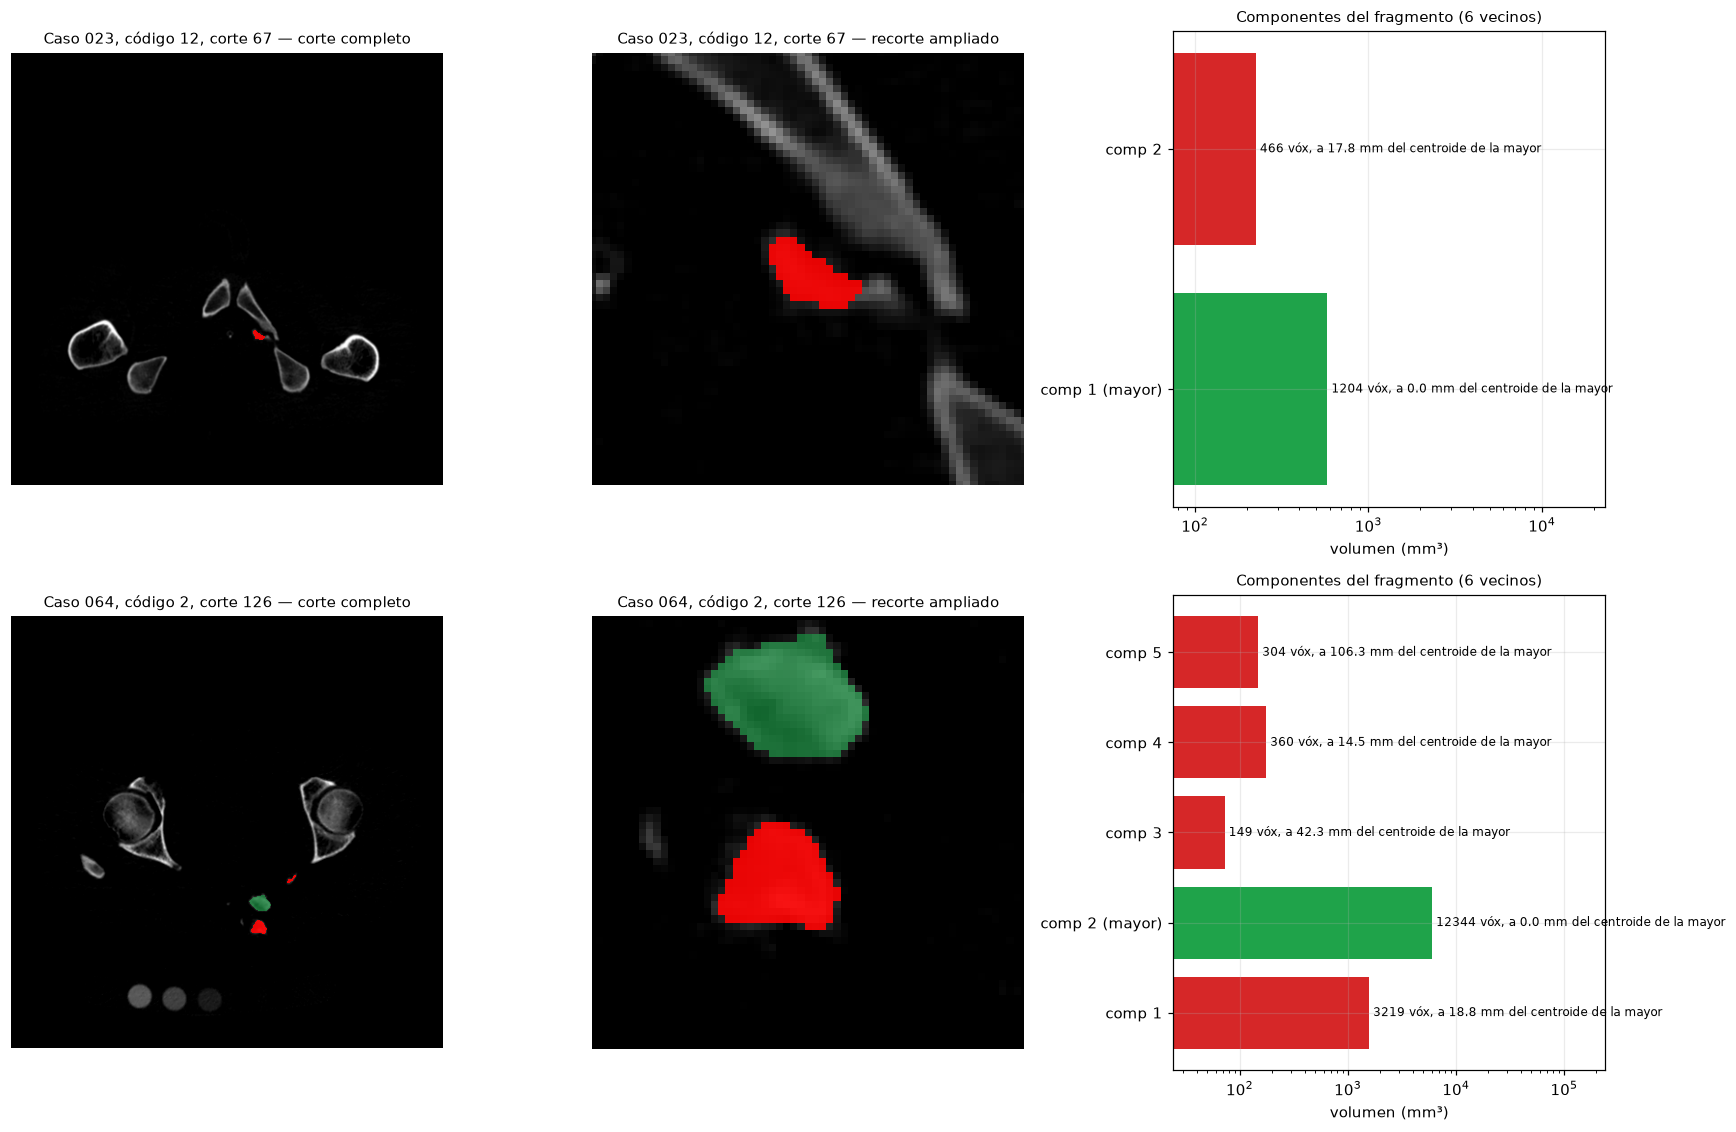

In [29]:
fig, axes = plt.subplots(len(FRAGMENTOS_CONECTIVIDAD), 3, figsize=(16, 5.2 * len(FRAGMENTOS_CONECTIVIDAD)), squeeze=False)
for fila_ax, (cid, code) in zip(axes, FRAGMENTOS_CONECTIVIDAD):
    r = pre.preprocess_file(img_paths[cid], lbl_paths[cid])
    a_i, a_m = r["hu"], r["mask"]
    esp_zyx = np.array(r["spacing"])[::-1]
    cc = sitk.GetArrayFromImage(sitk.ConnectedComponent(sitk.GetImageFromArray((a_m == code).astype(np.uint8)), False))
    tam = np.bincount(cc.ravel())[1:]
    principal = int(tam.argmax()) + 1
    secundarias = np.isin(cc, [k for k in range(1, len(tam) + 1) if k != principal])
    if not secundarias.any():
        for a in fila_ax: a.axis("off")
        fila_ax[0].set_title(f"Caso {cid}, código {code}: una sola componente")
        continue
    z = int(secundarias.reshape(cc.shape[0], -1).sum(1).argmax())
    ys, xs = np.nonzero(secundarias[z])
    cy, cx = int(ys.mean()), int(xs.mean())
    rgba = np.zeros((*cc.shape[1:], 4)); rgba[cc[z] == principal] = (0.1, 0.7, 0.3, 0.55); rgba[secundarias[z]] = (1.0, 0.0, 0.0, 0.9)
    m = 30
    for a, (y0, y1, x0, x1), t in zip(fila_ax[:2], [(0, cc.shape[1], 0, cc.shape[2]), (max(cy - m, 0), cy + m, max(cx - m, 0), cx + m)], ["corte completo", "recorte ampliado"]):
        a.imshow(np.clip(a_i[z], HU_LO, HU_HI), cmap="gray"); a.imshow(rgba, interpolation="nearest")
        a.set_ylim(y1, y0); a.set_xlim(x0, x1); a.axis("off")
        a.set_title(f"Caso {cid}, código {code}, corte {z} — {t}", fontsize=10)
    cen = {k: np.argwhere(cc == k).mean(0) * esp_zyx for k in range(1, len(tam) + 1)}
    dist = [np.linalg.norm(cen[k] - cen[principal]) for k in range(1, len(tam) + 1)]
    vox_mm3 = float(np.prod(r["spacing"]))
    etiquetas = [f"comp {k}{' (mayor)' if k == principal else ''}" for k in range(1, len(tam) + 1)]
    fila_ax[2].barh(etiquetas, tam * vox_mm3, color=["#1fa34a" if k == principal else "#d62728" for k in range(1, len(tam) + 1)])
    fila_ax[2].set_xscale("log"); fila_ax[2].set_xlabel("volumen (mm³)")
    fila_ax[2].set_xlim(tam.min() * vox_mm3 / 3, tam.max() * vox_mm3 * 40)
    for k, (t_, d_) in enumerate(zip(tam, dist)):
        fila_ax[2].text(tam[k] * vox_mm3, k, f" {t_} vóx, a {d_:.1f} mm del centroide de la mayor", va="center", fontsize=8)
    fila_ax[2].set_title("Componentes del fragmento (6 vecinos)", fontsize=10); fila_ax[2].grid(True, alpha=0.25)
plt.tight_layout()
plt.savefig(OUT_DIR / "connectivity_examples.png", bbox_inches="tight", dpi=150)
plt.show()

## Anomalías marcadas

Marcas por caso según reglas fijas (umbrales en la celda de parámetros). Las marcas no excluyen ningún caso. Severidad `revisar` = requiere revisión; `info` = dato relevante.

In [30]:
anom = []   # (case_id, severidad, marca, detalle)

# Rango de tolerancia (Tukey, ancho mínimo 0.05 mm) del espaciado del conjunto
vallas = {}
for eje in "xyz":
    q1, q3 = df[f"spacing_{eje}"].quantile([0.25, 0.75])
    ancho = max(q3 - q1, 0.05)
    vallas[eje] = (q1 - 1.5 * ancho, q3 + 1.5 * ancho)

for _, r in df.iterrows():
    cid = r.case_id
    codigos = [int(c) for c in str(r.codes).split()]
    invalidos = [c for c in codigos if not any(c in cods for cods in REGIONES.values())]
    if r.label_min < 0 or invalidos:
        anom.append((cid, "revisar", "label_codes_invalid", f"códigos fuera de 1-30: {invalidos}"))
    for reg in REGION_ORDER:
        if r[f"n_frag_{reg}"] == 0:
            anom.append((cid, "revisar", "missing_region", f"sin etiquetas de {reg}"))
    if not 3 <= r.n_fragments <= 12:
        anom.append((cid, "revisar", "fragment_count_out_of_range", f"{r.n_fragments} fragmentos (esperado 3-12)"))
    if not r.geometry_match:
        anom.append((cid, "revisar", "geometry_mismatch", "imagen y máscara difieren en tamaño, espaciado, origen o dirección"))
    if r.direction != "1 0 0 0 1 0 0 0 1":
        conocida = r.direction == "-1 0 0 0 -1 0 0 0 1"
        anom.append((cid, "info", "direction_not_identity", f"dirección original {r.direction} (orientación {r.orientation}); el pipeline la reorienta") if conocida
                     else (cid, "revisar", "direction_unknown", f"dirección original {r.direction}"))
    if r.anisotropia > UMBRAL_ANISOTROPIA:
        anom.append((cid, "revisar", "spacing_anisotropy", f"máx/mín del espaciado = {r.anisotropia:.2f}"))
    for eje in "xyz":
        lo, hi = vallas[eje]
        if not lo <= r[f"spacing_{eje}"] <= hi:
            anom.append((cid, "info", "spacing_outlier", f"spacing_{eje} = {r[f'spacing_{eje}']:.3f} fuera de [{lo:.3f}, {hi:.3f}]"))
    if any(abs(r[f"spacing_{e}"] - r[f"itk_orig_spacing_{e}"]) > 1e-3 for e in "xyz"):
        anom.append((cid, "info", "spacing_fields_differ", "ElementSpacing distinto de ITK_original_spacing"))
    if r.hu_min < -1100 or r.hu_max > 3100:
        anom.append((cid, "info", "hu_range", f"HU en [{r.hu_min}, {r.hu_max}]"))
    if r.bone_hu_p50 < UMBRAL_HU_OSEO_BAJO:
        anom.append((cid, "revisar", "bone_hu_low", f"mediana HU dentro de la máscara = {r.bone_hu_p50:.0f}"))
    if not r.izq_mayor_x_fisico:
        anom.append((cid, "revisar", "left_right_inconsistent", "el coxal 11-20 no queda a la izquierda en coordenadas físicas"))
    if r.frac_hueso_perdido_crop > 0:
        anom.append((cid, "revisar", "crop_cuts_bone", f"{100 * r.frac_hueso_perdido_crop:.2f} % del hueso etiquetado queda fuera del recorte ({r.frags_cortados_crop} fragmentos)"))
    if r.crop_pad_frac > 0.25:
        anom.append((cid, "info", "crop_padding", f"{100 * r.crop_pad_frac:.0f} % del recorte es relleno"))
    for reg in REGION_ORDER:
        if r[f"n_frag_{reg}"] > 1 and not r[f"codes_sorted_by_volume_{reg}"]:
            anom.append((cid, "info", "codes_not_sorted_by_volume", f"{reg}: los códigos no siguen el orden de volumen"))
        if r[f"n_frag_{reg}"] > 1 and not r[f"main_is_first_code_{reg}"]:
            anom.append((cid, "revisar", "main_fragment_not_first_code", f"{reg}: el fragmento de mayor volumen no es el de menor código"))

for _, f in df_frag.iterrows():
    if f.volume_mm3 < UMBRAL_FRAGMENTO_MM3:
        anom.append((f.case_id, "revisar", "fragment_small", f"código {f.code}: {f.volume_mm3:.0f} mm³"))
    if f.n_components_26 > 1:
        anom.append((f.case_id, "revisar", "fragment_multi_component_26", f"código {f.code}: {f.n_components_26} componentes (26 vecinos); mayor = {f.largest_component_frac_26:.1%}"))
    elif f.n_components_6 > 1:
        anom.append((f.case_id, "info", "fragment_multi_component_6_only", f"código {f.code}: {f.n_components_6} componentes solo con 6 vecinos"))

df_anom = pd.DataFrame(anom, columns=["case_id", "severity", "flag", "detail"])
df_anom.to_csv(OUT_DIR / "anomalies.csv", index=False)
display(df_anom.groupby(["severity", "flag"]).agg(marcas=("case_id", "size"), casos=("case_id", "nunique")).reset_index())
df_anom[(df_anom.severity == "revisar") & ~df_anom.flag.str.startswith("fragment_multi")].sort_values(["flag", "case_id"]).reset_index(drop=True)

,severity,flag,marcas,casos
0,info,codes_not_sorted_by_volume,45,43
1,info,crop_padding,31,31
2,info,direction_not_identity,34,34
3,info,fragment_multi_component_6_only,28,24
4,info,hu_range,61,61
5,info,spacing_fields_differ,100,100
6,info,spacing_outlier,14,7
7,revisar,bone_hu_low,1,1
8,revisar,crop_cuts_bone,2,2
9,revisar,fragment_multi_component_26,108,68


,case_id,severity,flag,detail
0,095,revisar,bone_hu_low,mediana HU dentro de la máscara = 79
1,016,revisar,crop_cuts_bone,2.39 % del hueso etiquetado queda fuera del re...
2,030,revisar,crop_cuts_bone,0.19 % del hueso etiquetado queda fuera del re...
3,052,revisar,fragment_small,código 23: 282 mm³
4,085,revisar,fragment_small,código 2: 313 mm³
5,039,revisar,spacing_anisotropy,máx/mín del espaciado = 1.53
6,047,revisar,spacing_anisotropy,máx/mín del espaciado = 1.67
7,086,revisar,spacing_anisotropy,máx/mín del espaciado = 1.52


## Ejemplos axiales

Corte axial con más vóxeles etiquetados de los casos de `CASOS_EJEMPLO`, tras el pipeline (reorientado y recortado), con la ventana HU y las etiquetas coloreadas por región.

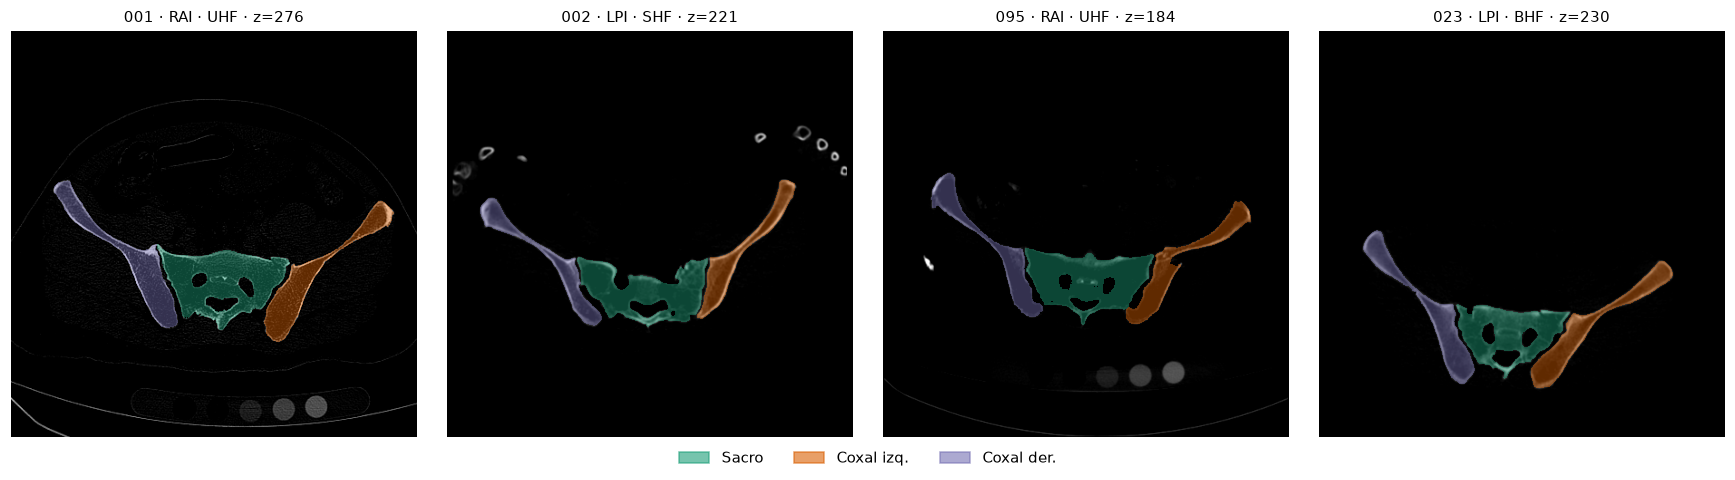

In [31]:
fig, axes = plt.subplots(1, len(CASOS_EJEMPLO), figsize=(4 * len(CASOS_EJEMPLO), 4.2))
for ax, c in zip(axes, CASOS_EJEMPLO):
    r = pre.preprocess_file(img_paths[c], lbl_paths[c])
    z = int((r["mask"] > 0).reshape(r["mask"].shape[0], -1).sum(1).argmax())
    ax.imshow(r["image"][z], cmap="gray", vmin=0, vmax=1)
    ax.imshow(np.ma.masked_equal(lut[np.clip(r["mask"][z], 0, 255)], 0), cmap=cmap_reg, vmin=0, vmax=3, alpha=0.45, interpolation="nearest")
    fila = df[df.case_id == c].iloc[0]
    ax.set_title(f"{c} · {fila.orientation} · {fila.fracture_type} · z={z}", fontsize=10); ax.axis("off")
fig.legend([plt.Rectangle((0, 0), 1, 1, color=COLOR_REGION[r], alpha=0.6) for r in REGION_ORDER], [NOMBRE_REGION[r] for r in REGION_ORDER],
           loc="lower center", ncol=3, frameon=False)
plt.tight_layout(rect=(0, 0.05, 1, 1))
plt.savefig(OUT_DIR / "examples_axial.png", bbox_inches="tight", dpi=150)
plt.show()

## Splits fijos

División train / val / test **por caso** (un caso = un paciente), estratificada por tipo de fractura y con semilla fija. Se generó una sola vez con `src/dataset/splits.py` y quedó guardada en `splits/splits.csv`; aquí solo se lee ese archivo para ver cómo quedaron repartidos los casos y las clases.

In [ ]:
splits = pd.read_csv(SPLITS_DIR / "splits.csv", dtype={"case_id": str})
assert splits.case_id.is_unique and set(splits.case_id) == set(df.case_id)

print(f"Splits leídos de {SPLITS_DIR / 'splits.csv'}:", splits.split.value_counts().to_dict())
display(pd.crosstab(splits.stratum, splits.split, margins=True))
display(pd.crosstab(splits.fracture_type, splits.split, margins=True))
for s in ("train", "val", "test"):
    print(f"{s:5s}: {', '.join(splits[splits.split == s].case_id)}")

In [33]:
m = df.merge(splits[["case_id", "split"]], on="case_id")
display(m.groupby("split")[["n_fragments", "spacing_x", "spacing_z", "anisotropia", "bone_volume_mm3", "bone_hu_p50"]].mean().round(2))
print("Casos por orientación original y split:")
display(pd.crosstab(m.orientation, m.split))
revisar = df_anom[(df_anom.severity == "revisar") & ~df_anom.flag.str.startswith("fragment_multi")].case_id.unique()
print("Casos con marcas 'revisar' (sin multi-componente) por split:", m[m.case_id.isin(revisar)].groupby("split").case_id.apply(list).to_dict())

,n_fragments,spacing_x,spacing_z,anisotropia,bone_volume_mm3,bone_hu_p50
split,,,,,,
test,5.93,0.87,0.84,1.12,736679.05,264.47
train,5.77,0.81,0.91,1.17,782278.58,280.89
val,5.47,0.82,0.87,1.15,819743.52,303.93


Casos por orientación original y split:


split,test,train,val
orientation,,,
LPI,3,27,4
RAI,12,43,11


Casos con marcas 'revisar' (sin multi-componente) por split: {'test': ['039', '052'], 'train': ['016', '030', '047', '086', '095'], 'val': ['085']}


## Guardado de tablas

In [34]:
df.to_csv(OUT_DIR / "case_table.csv", index=False)   # incluye las columnas derivadas
print("Tablas en", OUT_DIR.resolve(), ":", sorted(p.name for p in OUT_DIR.glob("*.csv")))

Tablas en /Users/estefania/Downloads/Proyecto 2/results/eda : ['anomalies.csv', 'case_table.csv', 'fragments.csv']
